In [ ]:
# ==============================================================
# CELL 1: LIBRARIES, SETTINGS AND SHARED FUNCTIONS
# ==============================================================
# This cell:
# 1. Installs the German holiday package.
# 2. Imports all required libraries.
# 3. fixes random seeds.
# 4. Creates safe string-based output folders.
# 5. Defines common evaluation and helper functions.
# ==============================================================

%pip install -q holidays

%matplotlib inline

# --------------------------------------------------------------
# Standard Python libraries
# --------------------------------------------------------------
import os
import sys
import json
import time
import random
import platform
import warnings

from itertools import product

# --------------------------------------------------------------
# Reproducibility settings
# --------------------------------------------------------------
os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# --------------------------------------------------------------
# Data handling and visualisation
# --------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from IPython.display import display

# --------------------------------------------------------------
# Statistical libraries
# --------------------------------------------------------------
import scipy
from scipy import stats

import statsmodels
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

# --------------------------------------------------------------
# Machine-learning libraries
# --------------------------------------------------------------
import sklearn

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error
)

# --------------------------------------------------------------
# Other required libraries
# --------------------------------------------------------------
import requests
import joblib
import holidays

# --------------------------------------------------------------
# TensorFlow and Keras
# --------------------------------------------------------------
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")


# ==============================================================
# PROJECT SETTINGS
# ==============================================================

RANDOM_SEED = 42
SEASONAL_PERIOD = 52
TEST_WEEKS = 104

START_DATE = "2015-01-01"
END_DATE = "2020-10-01"

BERLIN_LATITUDE = 52.52
BERLIN_LONGITUDE = 13.41

REFRESH_POLICIES = {
    "Frozen": None,
    "Annual": 52,
    "Semiannual": 26,
    "Quarterly": 13
}

# Fix random seeds.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


# ==============================================================
# SAFE OUTPUT FOLDERS
# ==============================================================
# Only normal strings and os.path.join() are used.
# pathlib is not used, preventing the earlier PosixPath error.

PROJECT_FOLDER = os.path.abspath(
    "german_demand_refresh_project"
)

FIGURE_FOLDER = os.path.join(
    PROJECT_FOLDER,
    "figures"
)

RESULT_FOLDER = os.path.join(
    PROJECT_FOLDER,
    "results"
)

MODEL_FOLDER = os.path.join(
    PROJECT_FOLDER,
    "models"
)

DATA_FOLDER = os.path.join(
    PROJECT_FOLDER,
    "data"
)

LOG_FOLDER = os.path.join(
    PROJECT_FOLDER,
    "logs"
)

for folder in [
    PROJECT_FOLDER,
    FIGURE_FOLDER,
    RESULT_FOLDER,
    MODEL_FOLDER,
    DATA_FOLDER,
    LOG_FOLDER
]:
    os.makedirs(folder, exist_ok=True)


# ==============================================================
# COMMON EVALUATION FUNCTIONS
# ==============================================================

def smape(actual, predicted):
    """
    Calculate Symmetric Mean Absolute Percentage Error.
    """

    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    if actual.shape != predicted.shape:
        raise ValueError(
            "Actual and predicted values must have the same shape."
        )

    denominator = np.abs(actual) + np.abs(predicted)
    valid = denominator != 0

    if not np.any(valid):
        return np.nan

    return float(
        np.mean(
            200
            * np.abs(actual[valid] - predicted[valid])
            / denominator[valid]
        )
    )


def seasonal_error_scales(
    training_series,
    seasonal_period=SEASONAL_PERIOD
):
    """
    Calculate training-only scaling values for MASE and RMSSE.
    """

    training_series = (
        pd.Series(training_series)
        .dropna()
        .astype(float)
    )

    if len(training_series) <= seasonal_period:
        raise ValueError(
            "Training data must be longer than the seasonal period."
        )

    seasonal_errors = (
        training_series.iloc[seasonal_period:].to_numpy()
        - training_series.iloc[:-seasonal_period].to_numpy()
    )

    mae_scale = np.mean(np.abs(seasonal_errors))
    mse_scale = np.mean(seasonal_errors ** 2)

    if mae_scale == 0 or mse_scale == 0:
        raise ValueError(
            "The seasonal scaling denominator is zero."
        )

    return float(mae_scale), float(mse_scale)


def evaluate_forecast(
    actual,
    predicted,
    training_series,
    model_name,
    seasonal_period=SEASONAL_PERIOD
):
    """
    Evaluate one forecast using the same metrics as all other models.

    Positive bias means average overprediction.
    Negative bias means average underprediction.
    """

    actual = pd.Series(actual).astype(float)
    predicted = pd.Series(predicted).astype(float)

    # Align predictions to the required test dates.
    predicted = predicted.reindex(actual.index)

    if predicted.isna().any():
        raise ValueError(
            f"{model_name} contains missing predictions."
        )

    actual_values = actual.to_numpy()
    predicted_values = predicted.to_numpy()

    errors = predicted_values - actual_values
    absolute_errors = np.abs(errors)

    mae = mean_absolute_error(
        actual_values,
        predicted_values
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_values,
            predicted_values
        )
    )

    mae_scale, mse_scale = seasonal_error_scales(
        training_series,
        seasonal_period
    )

    return {
        "Model": model_name,
        "MAE": float(mae),
        "RMSE": float(rmse),
        "sMAPE (%)": smape(
            actual_values,
            predicted_values
        ),
        "MASE": float(mae / mae_scale),
        "RMSSE": float(
            rmse / np.sqrt(mse_scale)
        ),
        "Median AE": float(
            median_absolute_error(
                actual_values,
                predicted_values
            )
        ),
        "90th percentile AE": float(
            np.percentile(
                absolute_errors,
                90
            )
        ),
        "Bias": float(np.mean(errors)),
        "Error stability": float(
            np.std(
                absolute_errors,
                ddof=1
            )
        )
    }


def evaluate_intervals(
    actual,
    lower,
    upper,
    model_name,
    alpha=0.05
):
    """
    Evaluate interval coverage, width and interval score.
    """

    actual = np.asarray(actual, dtype=float)
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)

    if not (
        actual.shape
        == lower.shape
        == upper.shape
    ):
        raise ValueError(
            "Actual, lower and upper values must have equal shapes."
        )

    if np.any(lower > upper):
        raise ValueError(
            "A lower interval limit is greater than its upper limit."
        )

    covered = (
        (actual >= lower)
        & (actual <= upper)
    )

    interval_width = upper - lower
    interval_score = interval_width.copy()

    below = actual < lower
    above = actual > upper

    interval_score[below] += (
        2 / alpha
    ) * (
        lower[below] - actual[below]
    )

    interval_score[above] += (
        2 / alpha
    ) * (
        actual[above] - upper[above]
    )

    return {
        "Model": model_name,
        "Coverage (%)": float(
            covered.mean() * 100
        ),
        "Mean width": float(
            interval_width.mean()
        ),
        "Interval score": float(
            interval_score.mean()
        )
    }


# ==============================================================
# STATIONARITY FUNCTION
# ==============================================================

def stationarity_result(series, series_name):
    """
    Run ADF and KPSS tests on one time series.
    """

    clean_series = (
        pd.Series(series)
        .dropna()
        .astype(float)
    )

    adf_output = adfuller(
        clean_series,
        autolag="AIC"
    )

    kpss_output = kpss(
        clean_series,
        regression="c",
        nlags="auto"
    )

    return {
        "Series": series_name,
        "ADF statistic": float(adf_output[0]),
        "ADF p-value": float(adf_output[1]),
        "KPSS statistic": float(kpss_output[0]),
        "KPSS p-value": float(kpss_output[1])
    }


# ==============================================================
# ALIGNMENT, REFRESH AND OUTPUT FUNCTIONS
# ==============================================================

def check_forecast_alignment(
    forecasts,
    expected_index
):
    """
    Confirm that all models forecast exactly the same dates.
    """

    expected_index = pd.DatetimeIndex(
        expected_index
    )

    for model_name, forecast in forecasts.items():

        forecast_index = pd.DatetimeIndex(
            pd.Series(forecast).index
        )

        if not forecast_index.equals(expected_index):
            raise ValueError(
                f"{model_name} does not use the common test dates."
            )

    print(
        "Alignment check passed: all forecasts use "
        "exactly the same dates."
    )


def make_refresh_schedule(
    test_length,
    refresh_interval
):
    """
    Return the starting position of each update segment.
    """

    if refresh_interval is None:
        return [0]

    if refresh_interval <= 0:
        raise ValueError(
            "Refresh interval must be greater than zero."
        )

    return list(
        range(
            0,
            test_length,
            refresh_interval
        )
    )


def maintenance_level(total_fits):
    """
    Assign a practical maintenance category.
    """

    if total_fits <= 1:
        return "Low"

    if total_fits <= 4:
        return "Moderate"

    return "High"


def save_figure(
    filename,
    figure=None,
    dpi=300
):
    """
    Save a figure without closing it.

    The plot remains visible because plt.show() is called afterwards.
    """

    if figure is None:
        figure = plt.gcf()

    filename = str(filename)

    if not filename.lower().endswith(".png"):
        filename += ".png"

    output_path = os.path.join(
        FIGURE_FOLDER,
        filename
    )

    figure.tight_layout()

    figure.savefig(
        output_path,
        dpi=dpi,
        bbox_inches="tight"
    )

    return output_path


# ==============================================================
# SHARED RESULT CONTAINERS
# ==============================================================

forecast_store = {}
metrics_store = []
interval_store = []


# ==============================================================
# ENVIRONMENT MANIFEST
# ==============================================================

environment_manifest = {
    "Python": sys.version.split()[0],
    "Platform": platform.platform(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "scipy": scipy.__version__,
    "statsmodels": statsmodels.__version__,
    "scikit-learn": sklearn.__version__,
    "tensorflow": tf.__version__,
    "joblib": joblib.__version__,
    "Random seed": RANDOM_SEED,
    "Seasonal period": SEASONAL_PERIOD,
    "Test weeks": TEST_WEEKS
}

manifest_path = os.path.join(
    LOG_FOLDER,
    "environment_manifest.json"
)

with open(
    manifest_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        environment_manifest,
        file,
        indent=4
    )


# ==============================================================
# REFRESH-POLICY SUMMARY
# ==============================================================

policy_rows = []

for policy_name, interval in REFRESH_POLICIES.items():

    schedule = make_refresh_schedule(
        TEST_WEEKS,
        interval
    )

    total_fits = len(schedule)

    policy_rows.append(
        {
            "Policy": policy_name,
            "Update interval": (
                "No update"
                if interval is None
                else f"Every {interval} weeks"
            ),
            "Updates after initial fit": total_fits - 1,
            "Total fits": total_fits,
            "Maintenance": maintenance_level(
                total_fits
            )
        }
    )

policy_summary = pd.DataFrame(
    policy_rows
)

print("=" * 70)
print("CELL 1 COMPLETED SUCCESSFULLY")
print("=" * 70)
print(f"Random seed     : {RANDOM_SEED}")
print(f"Seasonal period : {SEASONAL_PERIOD} weeks")
print(f"Test horizon    : {TEST_WEEKS} weeks")
print(f"Project folder  : {PROJECT_FOLDER}")

display(policy_summary)

CELL 1 COMPLETED SUCCESSFULLY
Random seed     : 42
Seasonal period : 52 weeks
Test horizon    : 104 weeks
Project folder  : /content/german_demand_refresh_project


,Policy,Update interval,Updates after initial fit,Total fits,Maintenance
0,Frozen,No update,0,1,Low
1,Annual,Every 52 weeks,1,2,Moderate
2,Semiannual,Every 26 weeks,3,4,Moderate
3,Quarterly,Every 13 weeks,7,8,High


In [ ]:
# ==============================================================
# CELL 2: DATA DOWNLOAD AND PREPARATION
# ==============================================================
# This cell:
# 1. Downloads German hourly electricity demand.
# 2. Creates hourly, daily and complete weekly series.
# 3. Downloads historical Berlin weather.
# 4. Creates German calendar variables.
# 5. Defines the 195-week training and 104-week test periods.
# ==============================================================


# ==============================================================
# 1. DOWNLOAD ELECTRICITY DATA
# ==============================================================

ELECTRICITY_URL = (
    "https://data.open-power-system-data.org/"
    "time_series/2020-10-06/"
    "time_series_60min_singleindex.csv"
)

electricity_file = os.path.join(
    DATA_FOLDER,
    "time_series_60min_singleindex.csv"
)

# Download the source file once and reuse it later.
if not os.path.exists(electricity_file):

    print("Downloading electricity data...")

    response = requests.get(
        ELECTRICITY_URL,
        stream=True,
        timeout=300
    )

    response.raise_for_status()

    with open(electricity_file, "wb") as file:

        for chunk in response.iter_content(
            chunk_size=1024 * 1024
        ):
            if chunk:
                file.write(chunk)

    print("Electricity data downloaded.")
else:
    print("Using previously downloaded electricity data.")


# Read the header to identify the German load column.
electricity_header = pd.read_csv(
    electricity_file,
    nrows=0
)

preferred_load_column = (
    "DE_load_actual_entsoe_transparency"
)

if preferred_load_column in electricity_header.columns:

    load_column = preferred_load_column

else:

    possible_load_columns = [
        column
        for column in electricity_header.columns
        if column.startswith("DE_load_actual")
    ]

    if len(possible_load_columns) == 0:
        raise ValueError(
            "No German electricity-load column was found."
        )

    load_column = possible_load_columns[0]

print(f"Selected demand column: {load_column}")


# Read only the required timestamp and demand columns.
electricity_raw = pd.read_csv(
    electricity_file,
    usecols=[
        "utc_timestamp",
        load_column
    ]
)

electricity_raw["utc_timestamp"] = pd.to_datetime(
    electricity_raw["utc_timestamp"],
    utc=True
).dt.tz_convert(None)

electricity_raw = (
    electricity_raw
    .set_index("utc_timestamp")
    .sort_index()
)

electricity_raw = electricity_raw.loc[
    (electricity_raw.index >= START_DATE)
    & (electricity_raw.index < END_DATE)
]


# ==============================================================
# 2. CREATE COMPLETE HOURLY SERIES
# ==============================================================

expected_hourly_index = pd.date_range(
    start=START_DATE,
    end=END_DATE,
    freq="h",
    inclusive="left"
)

hourly_load = (
    electricity_raw[load_column]
    .reindex(expected_hourly_index)
    .astype(float)
)

hourly_load.name = "demand"

missing_before = int(
    hourly_load.isna().sum()
)

# Interpolate isolated missing hourly values.
if missing_before > 0:

    hourly_load = hourly_load.interpolate(
        method="time",
        limit_direction="both"
    )

missing_after = int(
    hourly_load.isna().sum()
)

if missing_after > 0:
    raise ValueError(
        "Missing demand remains after interpolation."
    )


# ==============================================================
# 3. CREATE DAILY AND COMPLETE WEEKLY SERIES
# ==============================================================

daily_load = hourly_load.resample("D").mean()
daily_load.name = "demand"

hourly_frame = hourly_load.to_frame()

# W-SUN creates Monday-to-Sunday weeks.
hourly_frame["week_start"] = (
    hourly_frame.index
    .to_period("W-SUN")
    .start_time
)

weekly_groups = hourly_frame.groupby(
    "week_start"
)

weekly_counts = weekly_groups[
    "demand"
].count()

weekly_means = weekly_groups[
    "demand"
].mean()

# Retain only complete weeks with 168 hourly observations.
complete_week_index = weekly_counts.loc[
    weekly_counts == 168
].index

weekly_load = weekly_means.loc[
    complete_week_index
].copy()

weekly_load.index = pd.DatetimeIndex(
    weekly_load.index,
    name="week_start"
)

weekly_load.name = "demand"


# ==============================================================
# 4. DOWNLOAD BERLIN WEATHER
# ==============================================================

WEATHER_URL = (
    "https://archive-api.open-meteo.com/v1/archive"
)

weather_parameters = {
    "latitude": BERLIN_LATITUDE,
    "longitude": BERLIN_LONGITUDE,
    "start_date": START_DATE,
    "end_date": "2020-09-30",
    "daily": (
        "temperature_2m_mean,"
        "temperature_2m_min,"
        "temperature_2m_max"
    ),
    "timezone": "Europe/Berlin"
}

weather_response = requests.get(
    WEATHER_URL,
    params=weather_parameters,
    timeout=120
)

weather_response.raise_for_status()

weather_json = weather_response.json()

if "daily" not in weather_json:
    raise ValueError(
        "Weather API response does not contain daily data."
    )

weather_daily = pd.DataFrame(
    weather_json["daily"]
)

weather_daily["time"] = pd.to_datetime(
    weather_daily["time"]
)

weather_daily = (
    weather_daily
    .set_index("time")
    .sort_index()
)

weather_daily = weather_daily.rename(
    columns={
        "temperature_2m_mean": "temp_mean",
        "temperature_2m_min": "temp_min",
        "temperature_2m_max": "temp_max"
    }
)

# Heating degree days and cooling degree days.
weather_daily["hdd"] = np.maximum(
    18 - weather_daily["temp_mean"],
    0
)

weather_daily["cdd"] = np.maximum(
    weather_daily["temp_mean"] - 22,
    0
)

weather_daily["week_start"] = (
    weather_daily.index
    .to_period("W-SUN")
    .start_time
)

weather_weekly = weather_daily.groupby(
    "week_start"
).agg(
    temp_mean=("temp_mean", "mean"),
    temp_min=("temp_min", "min"),
    temp_max=("temp_max", "max"),
    hdd=("hdd", "mean"),
    cdd=("cdd", "mean"),
    weather_days=("temp_mean", "count")
)

weather_weekly = weather_weekly.loc[
    weather_weekly["weather_days"] == 7
].drop(
    columns="weather_days"
)

weather_weekly = weather_weekly.reindex(
    weekly_load.index
)

weather_weekly = weather_weekly.interpolate(
    method="linear",
    limit_direction="both"
)


# ==============================================================
# 5. CREATE GERMAN CALENDAR VARIABLES
# ==============================================================

calendar_dates = pd.date_range(
    start=START_DATE,
    end="2020-09-30",
    freq="D"
)

german_holidays = holidays.Germany(
    years=range(2015, 2021)
)

calendar_daily = pd.DataFrame(
    index=calendar_dates
)

calendar_daily["is_holiday"] = [
    int(date.date() in german_holidays)
    for date in calendar_daily.index
]

calendar_daily["is_weekday"] = (
    calendar_daily.index.dayofweek < 5
).astype(int)

calendar_daily["is_working_day"] = (
    (calendar_daily["is_weekday"] == 1)
    & (calendar_daily["is_holiday"] == 0)
).astype(int)

calendar_daily["christmas_new_year"] = [
    int(
        (
            date.month == 12
            and date.day >= 24
        )
        or (
            date.month == 1
            and date.day <= 1
        )
    )
    for date in calendar_daily.index
]

calendar_daily["week_start"] = (
    calendar_daily.index
    .to_period("W-SUN")
    .start_time
)

calendar_weekly = calendar_daily.groupby(
    "week_start"
).agg(
    holiday_days=("is_holiday", "sum"),
    working_days=("is_working_day", "sum"),
    christmas_new_year=(
        "christmas_new_year",
        "max"
    ),
    calendar_days=("is_holiday", "count")
)

calendar_weekly = calendar_weekly.loc[
    calendar_weekly["calendar_days"] == 7
].drop(
    columns="calendar_days"
)

calendar_weekly = calendar_weekly.reindex(
    weekly_load.index
)

week_number = (
    weekly_load.index
    .isocalendar()
    .week
    .astype(int)
)

calendar_weekly["week_sin"] = np.sin(
    2 * np.pi * week_number / 52
)

calendar_weekly["week_cos"] = np.cos(
    2 * np.pi * week_number / 52
)


# ==============================================================
# 6. COMBINE DEMAND, WEATHER AND CALENDAR DATA
# ==============================================================

weekly_exog = pd.concat(
    [
        weather_weekly,
        calendar_weekly
    ],
    axis=1
)

weekly_dataset = pd.concat(
    [
        weekly_load.rename("demand"),
        weekly_exog
    ],
    axis=1
)

if weekly_dataset.isna().sum().sum() > 0:

    print("Missing values by column:")
    display(
        weekly_dataset.isna().sum()
    )

    raise ValueError(
        "Missing values remain in the weekly dataset."
    )


# ==============================================================
# 7. CREATE COMMON TRAINING AND TEST PERIODS
# ==============================================================

train_weekly = weekly_load.iloc[
    :-TEST_WEEKS
].copy()

test_weekly = weekly_load.iloc[
    -TEST_WEEKS:
].copy()

train_exog = weekly_exog.loc[
    train_weekly.index
].copy()

test_exog = weekly_exog.loc[
    test_weekly.index
].copy()

test_start = test_weekly.index[0]

test_end = (
    test_weekly.index[-1]
    + pd.Timedelta(days=7)
)

hourly_train = hourly_load.loc[
    hourly_load.index < test_start
].copy()

hourly_test = hourly_load.loc[
    (hourly_load.index >= test_start)
    & (hourly_load.index < test_end)
].copy()


# ==============================================================
# 8. VALIDATE EXPECTED DATA SHAPES
# ==============================================================

if len(test_weekly) != TEST_WEEKS:
    raise ValueError(
        "The weekly test period does not contain 104 weeks."
    )

if len(hourly_test) != TEST_WEEKS * 168:
    raise ValueError(
        "The hourly test period does not contain 104 complete weeks."
    )


# ==============================================================
# 9. SAVE PREPARED DATA
# ==============================================================

weekly_dataset.to_csv(
    os.path.join(
        DATA_FOLDER,
        "prepared_weekly_data.csv"
    )
)

hourly_load.to_csv(
    os.path.join(
        DATA_FOLDER,
        "prepared_hourly_load.csv"
    )
)


# ==============================================================
# 10. DISPLAY DATA QUALITY SUMMARY
# ==============================================================

quality_summary = pd.DataFrame(
    {
        "Series": [
            "Hourly",
            "Daily",
            "Complete weekly",
            "Weekly training",
            "Weekly testing",
            "Hourly training",
            "Hourly testing"
        ],
        "Observations": [
            len(hourly_load),
            len(daily_load),
            len(weekly_load),
            len(train_weekly),
            len(test_weekly),
            len(hourly_train),
            len(hourly_test)
        ]
    }
)

print("=" * 70)
print("CELL 2 COMPLETED SUCCESSFULLY")
print("=" * 70)
print(f"Missing hourly values before repair: {missing_before}")
print(f"Missing hourly values after repair : {missing_after}")
print(
    f"Training period: "
    f"{train_weekly.index.min().date()} to "
    f"{train_weekly.index.max().date()}"
)
print(
    f"Testing period : "
    f"{test_weekly.index.min().date()} to "
    f"{test_weekly.index.max().date()}"
)

display(quality_summary)
display(weekly_dataset.head())

Electricity data downloaded.
Selected demand column: DE_load_actual_entsoe_transparency
CELL 2 COMPLETED SUCCESSFULLY
Missing hourly values before repair: 0
Missing hourly values after repair : 0
Training period: 2015-01-05 to 2018-09-24
Testing period : 2018-10-01 to 2020-09-21


,Series,Observations
0,Hourly,50400
1,Daily,2100
2,Complete weekly,299
3,Weekly training,195
4,Weekly testing,104
5,Hourly training,32856
6,Hourly testing,17472


,demand,temp_mean,temp_min,temp_max,hdd,cdd,holiday_days,working_days,christmas_new_year,week_sin,week_cos
week_start,,,,,,,,,,,
2015-01-05,56191.101190,3.885714,-0.5,11.6,14.114286,0.0,0,5,0,0.239316,0.970942
2015-01-12,57672.678571,4.900000,-2.9,11.2,13.100000,0.0,0,5,0,0.354605,0.935016
2015-01-19,58613.303571,0.028571,-3.6,3.4,17.971429,0.0,0,5,0,0.464723,0.885456
2015-01-26,58734.029762,1.414286,-1.2,4.7,16.585714,0.0,0,5,0,0.568065,0.822984
2015-02-02,59323.898810,-1.228571,-8.2,2.9,19.228571,0.0,0,5,0,0.663123,0.748511


CELL 3: EDA, DECOMPOSITION AND STATIONARITY
Training observations : 195
Testing observations  : 104
Training period       : 2015-01-05 to 2018-09-24
Testing period        : 2018-10-01 to 2020-09-21


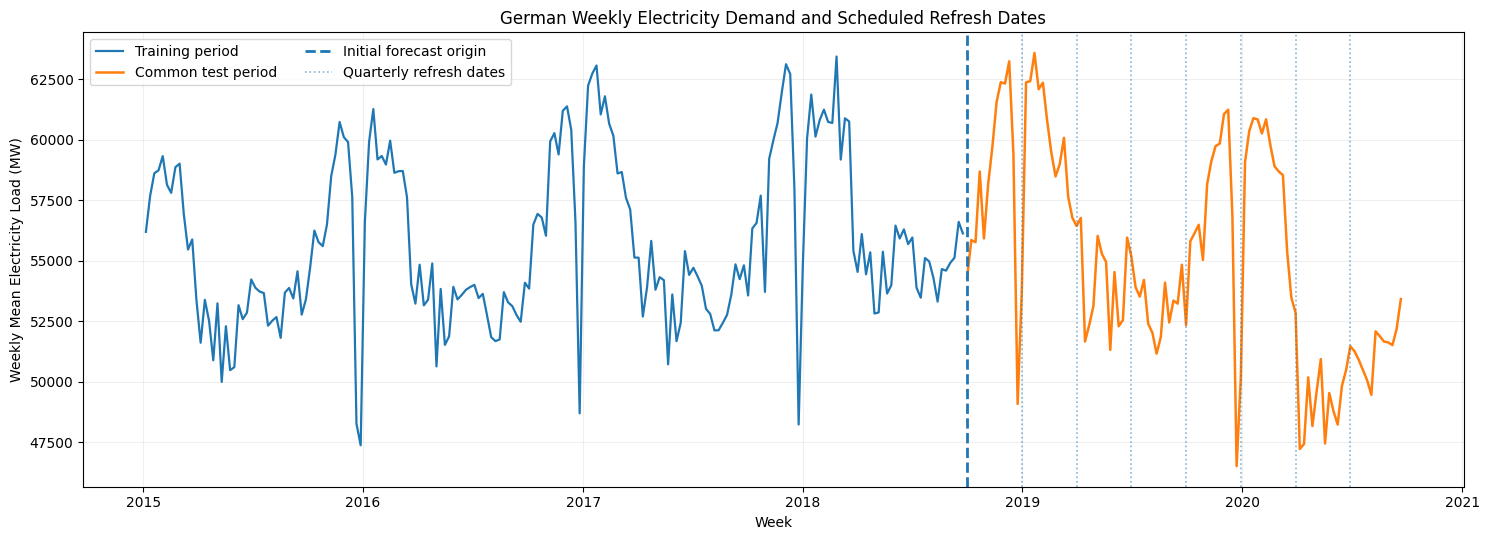

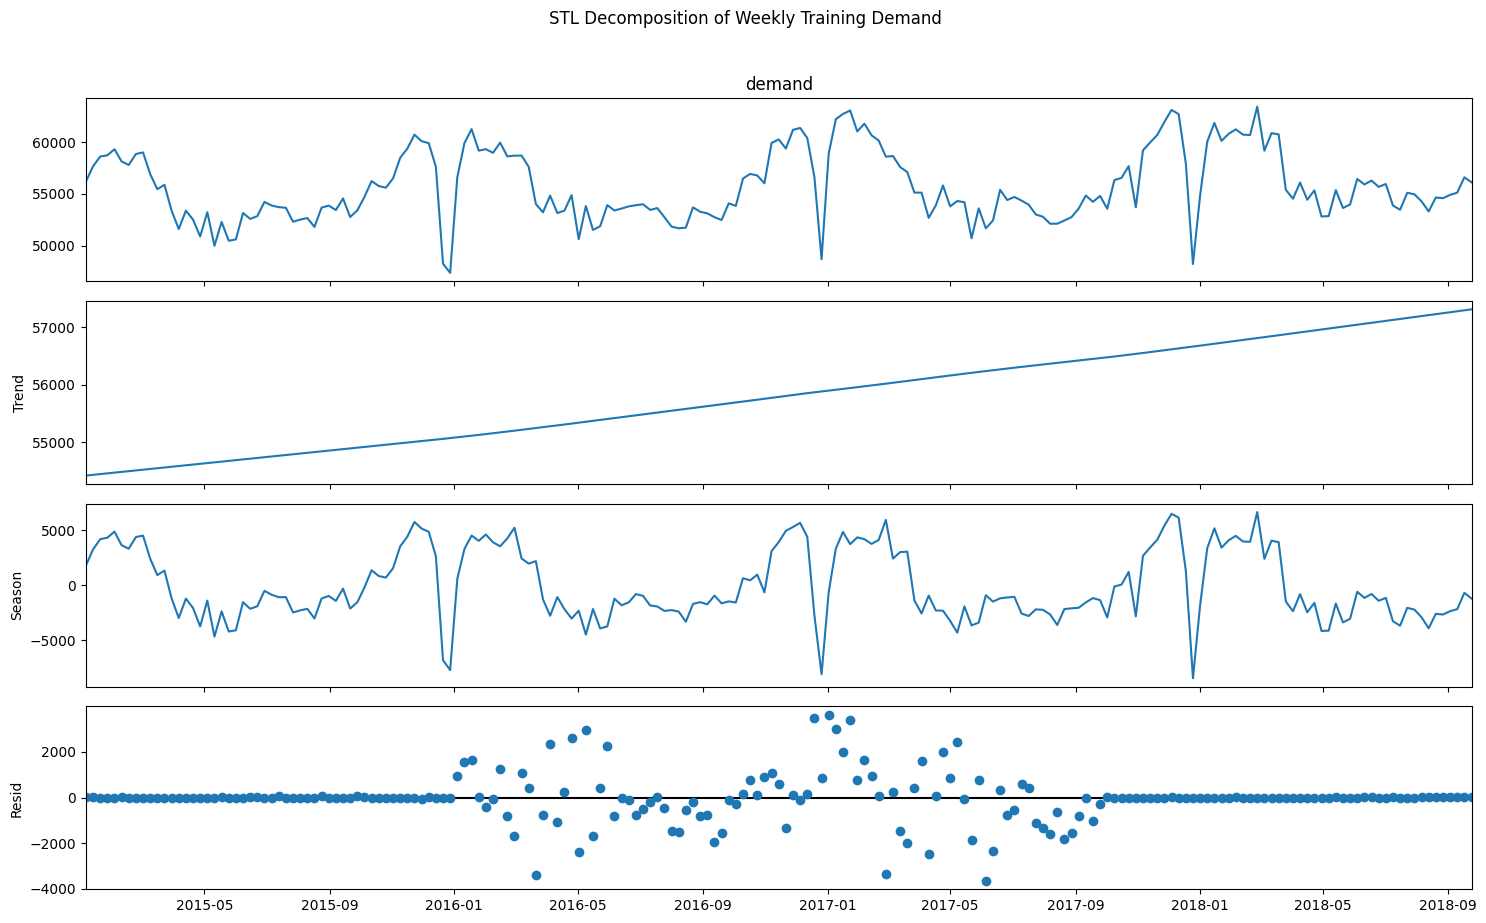

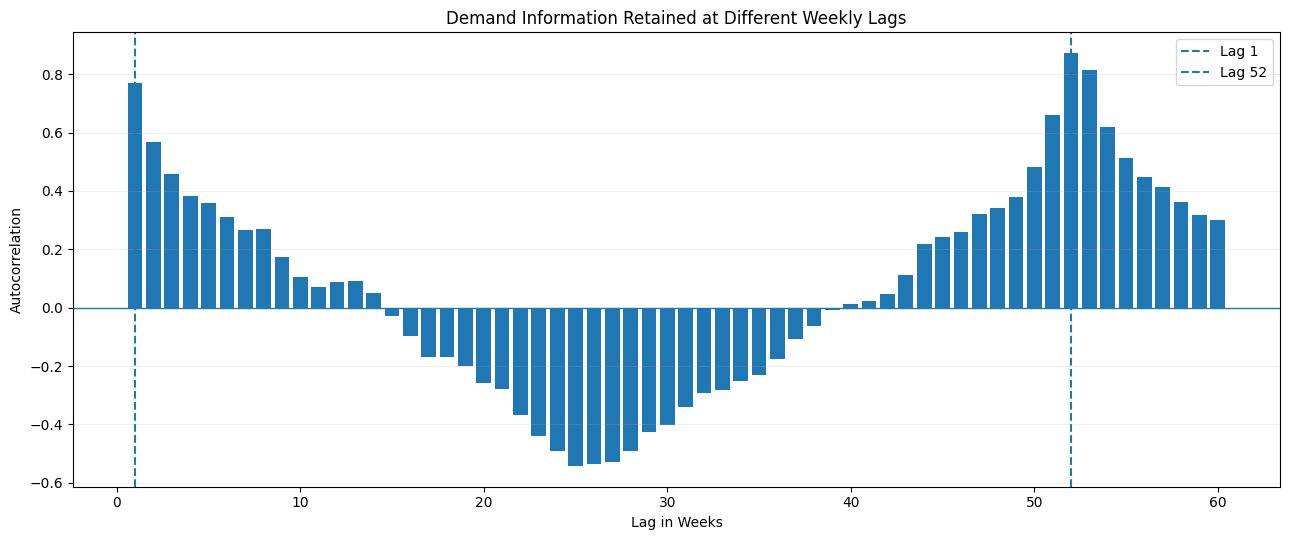


Important lag correlations:
Lag 1 correlation  : 0.7694
Lag 52 correlation : 0.8729

Transformation summary:


,Transformation,Observations,Mean,Standard deviation
0,Original,195,55700.7005,3345.7323
1,First difference,194,-0.3457,2278.0926
2,Seasonal difference,143,779.2342,1669.9725
3,First and seasonal difference,142,6.2839,2071.8488


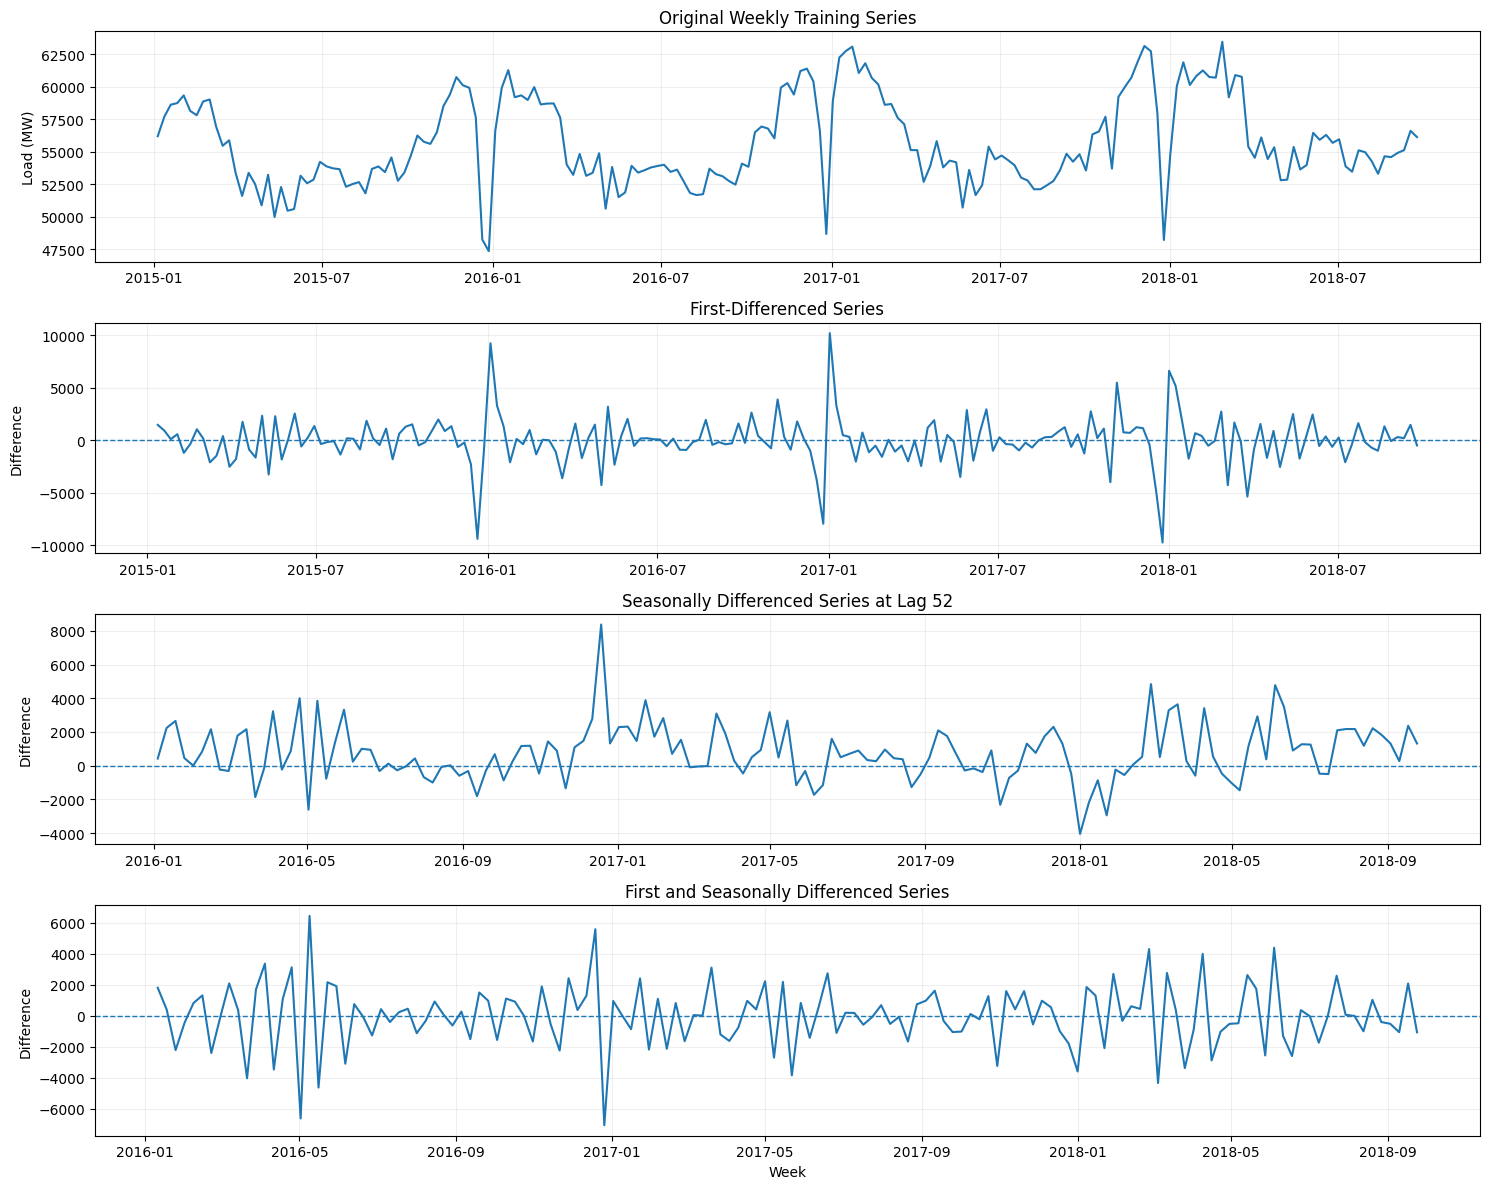


ADF and KPSS stationarity results:


,Series,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value,Interpretation
0,Original,-5.0030,0.0,0.1499,0.1,Evidence supports stationarity
1,First difference,-5.5708,0.0,0.0406,0.1,Evidence supports stationarity
2,Seasonal difference,-5.0395,0.0,0.0910,0.1,Evidence supports stationarity
3,First and seasonal difference,-6.7279,0.0,0.0138,0.1,Evidence supports stationarity


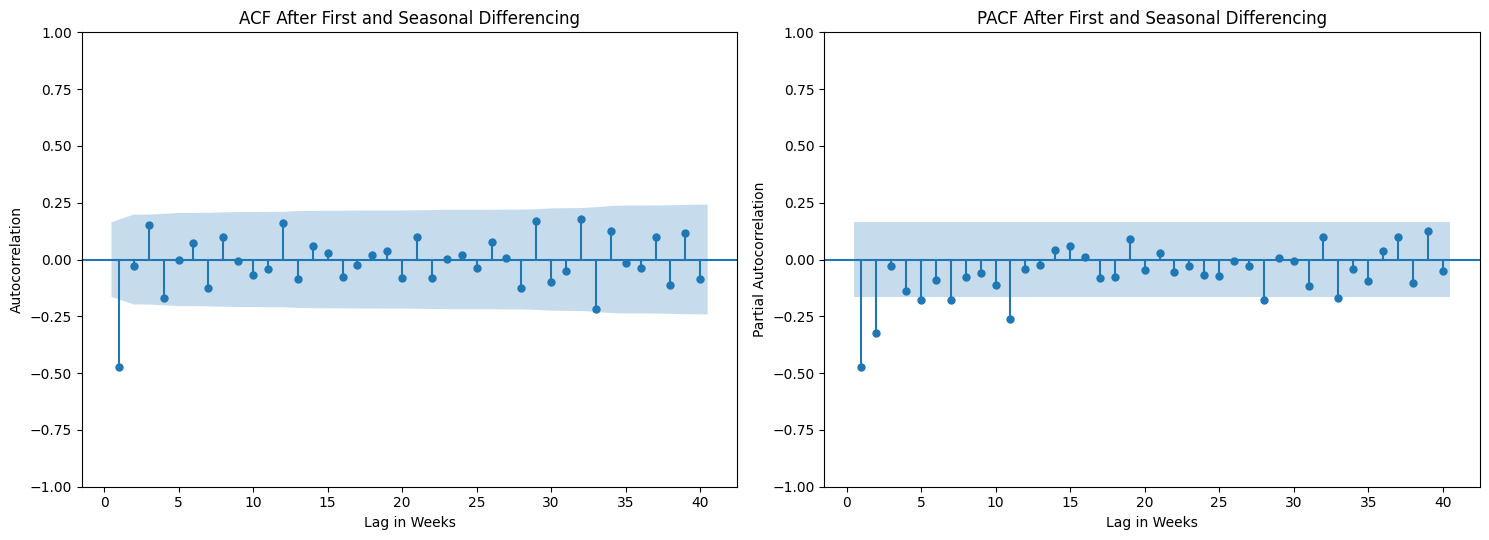

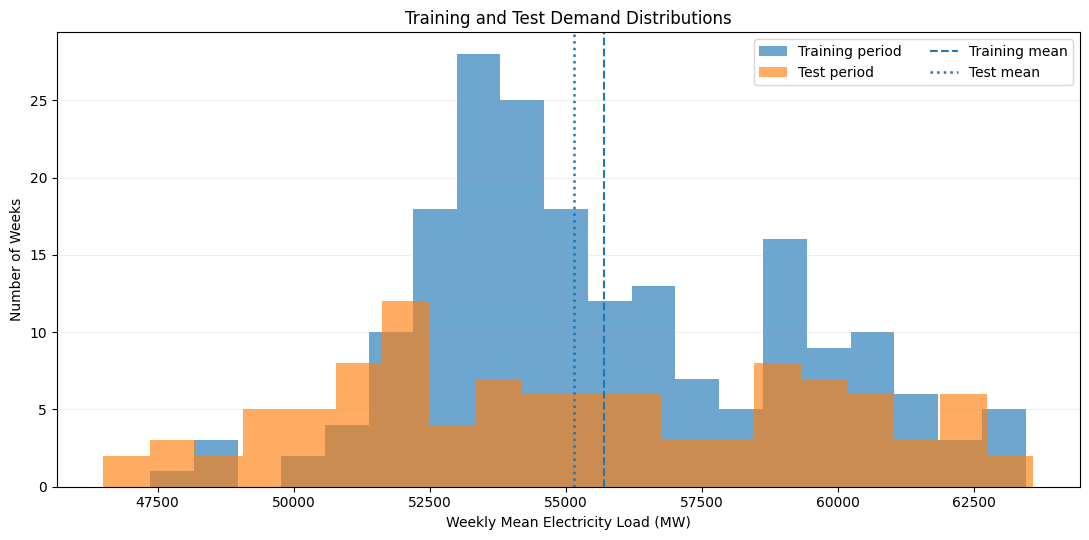


Training and test descriptive statistics:


,Period,Observations,Mean,Standard deviation,Minimum,Median,Maximum,Coefficient of variation (%)
0,Training,195,55700.7005,3345.7323,47364.0357,54858.4345,63442.0060,6.0066
1,Testing,104,55139.5081,4387.2844,46505.3095,54887.4137,63587.0119,7.9567



CELL 3 COMPLETED SUCCESSFULLY
Plots displayed and saved:
1. Weekly demand and refresh boundaries
2. STL decomposition
3. Weekly lag correlations
4. Original and differenced series
5. ACF and PACF
6. Training and test distributions


In [ ]:
# ==============================================================
# CELL 3: EDA, DECOMPOSITION AND STATIONARITY ANALYSIS
# ==============================================================
# This cell:
# 1. Displays weekly electricity demand and scheduled refresh dates.
# 2. Decomposes the training series into trend, seasonality and residuals.
# 3. Measures demand correlation across different weekly lags.
# 4. Tests stationarity using ADF and KPSS.
# 5. Displays the original and differenced series.
# 6. Produces safe ACF and PACF plots.
# 7. Compares training and testing demand distributions.
#
# Important:
# Stationarity tests, decomposition and autocorrelation analysis use
# only the training period. The test period is not used for model
# identification.
# ==============================================================


# ==============================================================
# 1. BASIC DATA CHECKS
# ==============================================================

# Confirm that the required variables from Cells 1 and 2 exist.
required_variables = [
    "train_weekly",
    "test_weekly",
    "SEASONAL_PERIOD",
    "RESULT_FOLDER"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "Run Cells 1 and 2 before Cell 3. Missing variables: "
        + ", ".join(missing_variables)
    )

# Ensure that both series are numeric, ordered and free from missing values.
train_weekly = (
    pd.Series(train_weekly)
    .sort_index()
    .astype(float)
)

test_weekly = (
    pd.Series(test_weekly)
    .sort_index()
    .astype(float)
)

if train_weekly.isna().any():
    raise ValueError(
        "The weekly training series contains missing values."
    )

if test_weekly.isna().any():
    raise ValueError(
        "The weekly test series contains missing values."
    )

if len(train_weekly) <= SEASONAL_PERIOD:
    raise ValueError(
        "The training series is too short for annual weekly analysis."
    )

print("=" * 72)
print("CELL 3: EDA, DECOMPOSITION AND STATIONARITY")
print("=" * 72)

print(
    f"Training observations : {len(train_weekly)}"
)

print(
    f"Testing observations  : {len(test_weekly)}"
)

print(
    f"Training period       : "
    f"{train_weekly.index.min().date()} to "
    f"{train_weekly.index.max().date()}"
)

print(
    f"Testing period        : "
    f"{test_weekly.index.min().date()} to "
    f"{test_weekly.index.max().date()}"
)


# ==============================================================
# PLOT 1: WEEKLY DEMAND AND QUARTERLY REFRESH DATES
# ==============================================================

fig, ax = plt.subplots(
    figsize=(15, 5.5)
)

# Training observations.
ax.plot(
    train_weekly.index,
    train_weekly.values,
    linewidth=1.6,
    label="Training period"
)

# Common two-year test period.
ax.plot(
    test_weekly.index,
    test_weekly.values,
    linewidth=1.8,
    label="Common test period"
)

# Initial forecast origin separating training and testing.
ax.axvline(
    test_weekly.index[0],
    linestyle="--",
    linewidth=2,
    label="Initial forecast origin"
)

# Positions for quarterly model updates.
quarterly_positions = make_refresh_schedule(
    test_length=len(test_weekly),
    refresh_interval=13
)

# Add the later quarterly update boundaries.
for update_number, position in enumerate(
    quarterly_positions[1:],
    start=1
):
    ax.axvline(
        test_weekly.index[position],
        linestyle=":",
        linewidth=1.2,
        alpha=0.55,
        label=(
            "Quarterly refresh dates"
            if update_number == 1
            else None
        )
    )

ax.set_title(
    "German Weekly Electricity Demand and Scheduled Refresh Dates"
)

ax.set_xlabel("Week")

ax.set_ylabel(
    "Weekly Mean Electricity Load (MW)"
)

ax.legend(
    ncol=2
)

ax.grid(
    alpha=0.20
)

save_figure(
    filename="weekly_demand_refresh_boundaries",
    figure=fig
)

plt.show()


# ==============================================================
# PLOT 2: STL DECOMPOSITION OF TRAINING DATA
# ==============================================================

# STL separates the training series into:
# - observed demand;
# - long-term trend;
# - annual seasonal pattern;
# - unexplained remainder.

stl_model = STL(
    train_weekly,
    period=SEASONAL_PERIOD,
    robust=True
)

stl_result = stl_model.fit()

fig = stl_result.plot()

fig.set_size_inches(
    15,
    9
)

fig.suptitle(
    "STL Decomposition of Weekly Training Demand",
    y=1.02
)

save_figure(
    filename="training_stl_decomposition",
    figure=fig
)

plt.show()


# ==============================================================
# PLOT 3: WEEKLY LAG CORRELATIONS
# ==============================================================

# Calculate autocorrelation for lags 1 to 60.
# Lag 1 represents short-term persistence.
# Lag 52 represents approximate annual recurrence.

maximum_lag = min(
    60,
    len(train_weekly) - 2
)

lag_correlations = pd.Series(
    {
        lag: train_weekly.autocorr(
            lag=lag
        )
        for lag in range(
            1,
            maximum_lag + 1
        )
    },
    name="Correlation"
)

fig, ax = plt.subplots(
    figsize=(13, 5.5)
)

ax.bar(
    lag_correlations.index,
    lag_correlations.values
)

ax.axhline(
    0,
    linewidth=1
)

ax.axvline(
    1,
    linestyle="--",
    linewidth=1.5,
    label="Lag 1"
)

if 52 in lag_correlations.index:
    ax.axvline(
        52,
        linestyle="--",
        linewidth=1.5,
        label="Lag 52"
    )

ax.set_title(
    "Demand Information Retained at Different Weekly Lags"
)

ax.set_xlabel(
    "Lag in Weeks"
)

ax.set_ylabel(
    "Autocorrelation"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.20
)

save_figure(
    filename="weekly_lag_correlations",
    figure=fig
)

plt.show()

print("\nImportant lag correlations:")

print(
    f"Lag 1 correlation  : "
    f"{lag_correlations.loc[1]:.4f}"
)

if 52 in lag_correlations.index:
    print(
        f"Lag 52 correlation : "
        f"{lag_correlations.loc[52]:.4f}"
    )


# ==============================================================
# 4. CREATE STATIONARITY TRANSFORMATIONS
# ==============================================================

# Original weekly training series.
original_series = train_weekly.copy()

# First difference removes consecutive-week level changes.
first_difference = (
    train_weekly
    .diff()
    .dropna()
)

# Seasonal difference compares demand with the same week one year earlier.
seasonal_difference = (
    train_weekly
    .diff(SEASONAL_PERIOD)
    .dropna()
)

# Combined transformation applies both first and annual differencing.
combined_difference = (
    train_weekly
    .diff()
    .diff(SEASONAL_PERIOD)
    .dropna()
)

transformation_summary = pd.DataFrame(
    {
        "Transformation": [
            "Original",
            "First difference",
            "Seasonal difference",
            "First and seasonal difference"
        ],
        "Observations": [
            len(original_series),
            len(first_difference),
            len(seasonal_difference),
            len(combined_difference)
        ],
        "Mean": [
            original_series.mean(),
            first_difference.mean(),
            seasonal_difference.mean(),
            combined_difference.mean()
        ],
        "Standard deviation": [
            original_series.std(),
            first_difference.std(),
            seasonal_difference.std(),
            combined_difference.std()
        ]
    }
)

print("\nTransformation summary:")

display(
    transformation_summary.round(4)
)


# ==============================================================
# PLOT 4: ORIGINAL AND DIFFERENCED SERIES
# ==============================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(15, 12)
)

axes[0].plot(
    original_series.index,
    original_series.values
)

axes[0].set_title(
    "Original Weekly Training Series"
)

axes[0].set_ylabel("Load (MW)")


axes[1].plot(
    first_difference.index,
    first_difference.values
)

axes[1].axhline(
    0,
    linestyle="--",
    linewidth=1
)

axes[1].set_title(
    "First-Differenced Series"
)

axes[1].set_ylabel("Difference")


axes[2].plot(
    seasonal_difference.index,
    seasonal_difference.values
)

axes[2].axhline(
    0,
    linestyle="--",
    linewidth=1
)

axes[2].set_title(
    "Seasonally Differenced Series at Lag 52"
)

axes[2].set_ylabel("Difference")


axes[3].plot(
    combined_difference.index,
    combined_difference.values
)

axes[3].axhline(
    0,
    linestyle="--",
    linewidth=1
)

axes[3].set_title(
    "First and Seasonally Differenced Series"
)

axes[3].set_xlabel("Week")

axes[3].set_ylabel("Difference")

for axis in axes:
    axis.grid(
        alpha=0.20
    )

save_figure(
    filename="original_and_differenced_series",
    figure=fig
)

plt.show()


# ==============================================================
# 5. ADF AND KPSS STATIONARITY TESTS
# ==============================================================

# The stationarity_result() function was defined in Cell 1.
#
# ADF null hypothesis:
# The series contains a unit root.
#
# KPSS null hypothesis:
# The series is stationary.

stationarity_results = pd.DataFrame(
    [
        stationarity_result(
            original_series,
            "Original"
        ),
        stationarity_result(
            first_difference,
            "First difference"
        ),
        stationarity_result(
            seasonal_difference,
            "Seasonal difference"
        ),
        stationarity_result(
            combined_difference,
            "First and seasonal difference"
        )
    ]
)

stationarity_results = (
    stationarity_results
    .round(4)
)

# Add a simple combined interpretation.
stationarity_results["Interpretation"] = np.select(
    [
        (
            stationarity_results["ADF p-value"] < 0.05
        )
        & (
            stationarity_results["KPSS p-value"] >= 0.05
        ),
        (
            stationarity_results["ADF p-value"] >= 0.05
        )
        & (
            stationarity_results["KPSS p-value"] < 0.05
        ),
        (
            stationarity_results["ADF p-value"] < 0.05
        )
        & (
            stationarity_results["KPSS p-value"] < 0.05
        )
    ],
    [
        "Evidence supports stationarity",
        "Evidence supports non-stationarity",
        "Conflicting evidence"
    ],
    default="Inconclusive evidence"
)

print("\nADF and KPSS stationarity results:")

display(
    stationarity_results
)

stationarity_results.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "stationarity_results.csv"
    ),
    index=False
)


# ==============================================================
# PLOT 5: ACF AND PACF AFTER COMBINED DIFFERENCING
# ==============================================================

# PACF requires the requested lag count to remain below
# approximately half of the available observations.
# This calculation prevents an invalid lag-length error.

safe_acf_lags = min(
    40,
    len(combined_difference) - 1
)

safe_pacf_lags = min(
    40,
    (len(combined_difference) // 2) - 1
)

if safe_acf_lags < 1 or safe_pacf_lags < 1:
    raise ValueError(
        "The combined differenced series is too short "
        "for ACF and PACF analysis."
    )

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5.5)
)

plot_acf(
    combined_difference,
    lags=safe_acf_lags,
    zero=False,
    ax=axes[0]
)

axes[0].set_title(
    "ACF After First and Seasonal Differencing"
)

axes[0].set_xlabel(
    "Lag in Weeks"
)

axes[0].set_ylabel(
    "Autocorrelation"
)


plot_pacf(
    combined_difference,
    lags=safe_pacf_lags,
    zero=False,
    method="ywm",
    ax=axes[1]
)

axes[1].set_title(
    "PACF After First and Seasonal Differencing"
)

axes[1].set_xlabel(
    "Lag in Weeks"
)

axes[1].set_ylabel(
    "Partial Autocorrelation"
)

save_figure(
    filename="acf_pacf_differenced_training",
    figure=fig
)

plt.show()


# ==============================================================
# PLOT 6: TRAINING AND TEST DEMAND DISTRIBUTIONS
# ==============================================================

fig, ax = plt.subplots(
    figsize=(11, 5.5)
)

ax.hist(
    train_weekly.values,
    bins=20,
    alpha=0.65,
    label="Training period"
)

ax.hist(
    test_weekly.values,
    bins=20,
    alpha=0.65,
    label="Test period"
)

# Show the mean of each period.
ax.axvline(
    train_weekly.mean(),
    linestyle="--",
    linewidth=1.5,
    label="Training mean"
)

ax.axvline(
    test_weekly.mean(),
    linestyle=":",
    linewidth=1.8,
    label="Test mean"
)

ax.set_title(
    "Training and Test Demand Distributions"
)

ax.set_xlabel(
    "Weekly Mean Electricity Load (MW)"
)

ax.set_ylabel(
    "Number of Weeks"
)

ax.legend(
    ncol=2
)

ax.grid(
    axis="y",
    alpha=0.20
)

save_figure(
    filename="training_test_distribution",
    figure=fig
)

plt.show()


# ==============================================================
# 6. TRAINING AND TEST DESCRIPTIVE STATISTICS
# ==============================================================

distribution_summary = pd.DataFrame(
    {
        "Period": [
            "Training",
            "Testing"
        ],
        "Observations": [
            len(train_weekly),
            len(test_weekly)
        ],
        "Mean": [
            train_weekly.mean(),
            test_weekly.mean()
        ],
        "Standard deviation": [
            train_weekly.std(),
            test_weekly.std()
        ],
        "Minimum": [
            train_weekly.min(),
            test_weekly.min()
        ],
        "Median": [
            train_weekly.median(),
            test_weekly.median()
        ],
        "Maximum": [
            train_weekly.max(),
            test_weekly.max()
        ]
    }
)

distribution_summary["Coefficient of variation (%)"] = (
    distribution_summary["Standard deviation"]
    / distribution_summary["Mean"]
    * 100
)

print("\nTraining and test descriptive statistics:")

display(
    distribution_summary.round(4)
)

distribution_summary.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "training_test_distribution_summary.csv"
    ),
    index=False
)


# ==============================================================
# 7. SAVE LAG-CORRELATION RESULTS
# ==============================================================

lag_correlation_table = (
    lag_correlations
    .rename_axis("Lag")
    .reset_index()
)

lag_correlation_table.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "weekly_lag_correlations.csv"
    ),
    index=False
)


# ==============================================================
# 8. FINAL CELL CONFIRMATION
# ==============================================================

print("\n" + "=" * 72)
print("CELL 3 COMPLETED SUCCESSFULLY")
print("=" * 72)

print(
    "Plots displayed and saved:"
)

print(
    "1. Weekly demand and refresh boundaries"
)

print(
    "2. STL decomposition"
)

print(
    "3. Weekly lag correlations"
)

print(
    "4. Original and differenced series"
)

print(
    "5. ACF and PACF"
)

print(
    "6. Training and test distributions"
)

Alignment check passed: all forecasts use exactly the same dates.


,Model,MAE,RMSE,sMAPE (%),MASE,RMSSE,Median AE,90th percentile AE,Bias,Error stability
3,Seasonal Naive,2288.4892,2988.2483,4.2067,1.6938,1.6262,1703.6875,4894.1970,1747.8046,1930.8791
0,Mean,3789.8453,4402.0588,6.8738,2.8051,2.3956,3737.3382,6676.3686,561.1923,2250.3079
2,Drift,3850.7758,4466.4944,6.9823,2.8502,2.4307,3776.0060,6617.6209,966.3860,2273.9432
1,Naive,3858.1478,4475.7671,6.9954,2.8556,2.4358,3790.3512,6650.1137,984.5335,2279.7279


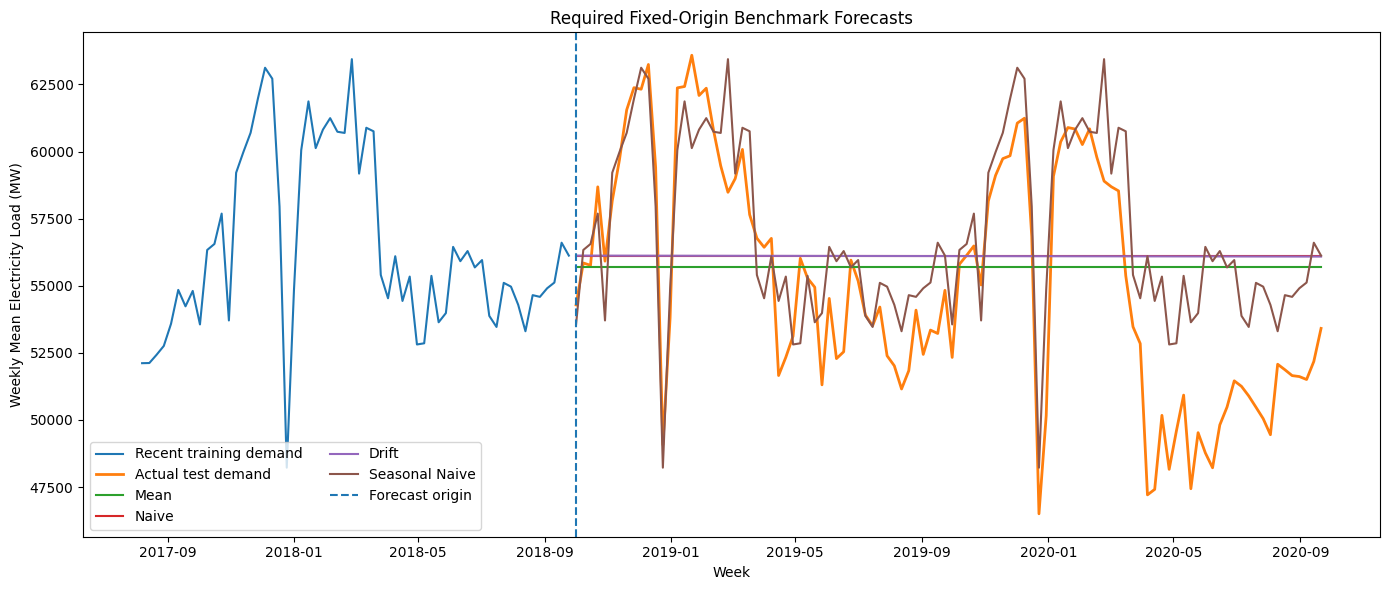

Cell 4 completed successfully.


In [ ]:
# ==============================================================
# CELL 4: FIXED-ORIGIN BENCHMARK FORECASTS
# ==============================================================
# All benchmark models forecast the same 104 weeks from one
# common forecast origin.
# ==============================================================

forecast_index = test_weekly.index
forecast_horizon = len(test_weekly)


# Remove older benchmark results when rerunning this cell.
benchmark_names = [
    "Mean",
    "Naive",
    "Drift",
    "Seasonal Naive"
]

metrics_store[:] = [
    result
    for result in metrics_store
    if result["Model"] not in benchmark_names
]


# ==============================================================
# 1. MEAN FORECAST
# ==============================================================

mean_forecast = pd.Series(
    np.repeat(
        train_weekly.mean(),
        forecast_horizon
    ),
    index=forecast_index,
    name="Mean"
)


# ==============================================================
# 2. NAIVE FORECAST
# ==============================================================

naive_forecast = pd.Series(
    np.repeat(
        train_weekly.iloc[-1],
        forecast_horizon
    ),
    index=forecast_index,
    name="Naive"
)


# ==============================================================
# 3. DRIFT FORECAST
# ==============================================================

drift_per_week = (
    train_weekly.iloc[-1]
    - train_weekly.iloc[0]
) / (
    len(train_weekly) - 1
)

drift_steps = np.arange(
    1,
    forecast_horizon + 1
)

drift_forecast = pd.Series(
    train_weekly.iloc[-1]
    + drift_steps * drift_per_week,
    index=forecast_index,
    name="Drift"
)


# ==============================================================
# 4. SEASONAL NAIVE FORECAST
# ==============================================================

last_annual_cycle = train_weekly.iloc[
    -SEASONAL_PERIOD:
].to_numpy()

required_repetitions = int(
    np.ceil(
        forecast_horizon
        / SEASONAL_PERIOD
    )
)

seasonal_values = np.tile(
    last_annual_cycle,
    required_repetitions
)[:forecast_horizon]

seasonal_naive_forecast = pd.Series(
    seasonal_values,
    index=forecast_index,
    name="Seasonal Naive"
)


# ==============================================================
# 5. STORE AND EVALUATE BENCHMARKS
# ==============================================================

benchmark_forecasts = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Drift": drift_forecast,
    "Seasonal Naive": seasonal_naive_forecast
}

for model_name, forecast in benchmark_forecasts.items():

    forecast_store[model_name] = forecast

    metrics_store.append(
        evaluate_forecast(
            actual=test_weekly,
            predicted=forecast,
            training_series=train_weekly,
            model_name=model_name
        )
    )

check_forecast_alignment(
    benchmark_forecasts,
    forecast_index
)

benchmark_metrics = pd.DataFrame(
    [
        result
        for result in metrics_store
        if result["Model"] in benchmark_names
    ]
).sort_values("RMSE")

display(
    benchmark_metrics.round(4)
)


# ==============================================================
# PLOT: BENCHMARK FORECASTS
# ==============================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    train_weekly.index[-60:],
    train_weekly.iloc[-60:],
    label="Recent training demand"
)

ax.plot(
    test_weekly.index,
    test_weekly.values,
    linewidth=2,
    label="Actual test demand"
)

for model_name, forecast in benchmark_forecasts.items():

    ax.plot(
        forecast.index,
        forecast.values,
        label=model_name
    )

ax.axvline(
    test_weekly.index[0],
    linestyle="--",
    label="Forecast origin"
)

ax.set_title(
    "Required Fixed-Origin Benchmark Forecasts"
)

ax.set_xlabel("Week")
ax.set_ylabel(
    "Weekly Mean Electricity Load (MW)"
)

ax.legend(
    ncol=2
)

save_figure(
    "benchmark_forecasts",
    fig
)

plt.show()

print("Cell 4 completed successfully.")

Testing 147 SARIMA combinations...
Completed 20/147
Completed 40/147
Completed 60/147
Completed 80/147
Completed 100/147
Completed 120/147
Completed 140/147

Top SARIMA candidates:


,order,AIC,Converged,Status
0,"(3, 2, 6)",1443.921,False,Successful
1,"(2, 2, 6)",1446.307,True,Successful
2,"(1, 2, 6)",1448.958,True,Successful
3,"(5, 2, 6)",1449.251,False,Successful
4,"(4, 2, 6)",1449.769,True,Successful
5,"(0, 2, 6)",1450.478,True,Successful
6,"(0, 1, 6)",1451.516,True,Successful
7,"(1, 1, 6)",1455.809,True,Successful
8,"(5, 1, 6)",1456.956,False,Successful
9,"(2, 1, 6)",1457.765,True,Successful


Selected order : (3, 2, 6)
Seasonal order : (0, 1, 1, 52)
Search time    : 6316.48 seconds
Ljung-Box test:


,lb_stat,lb_pvalue
12,12.4212,0.4125
26,32.2827,0.1839
52,47.4676,0.6525


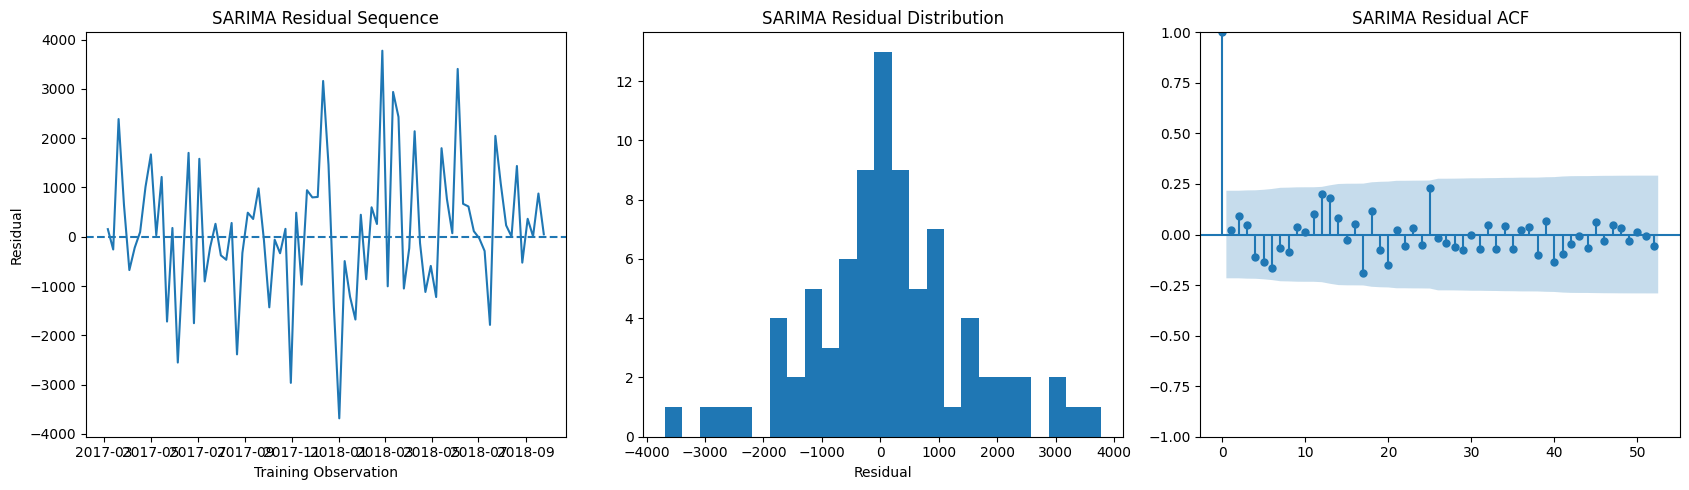

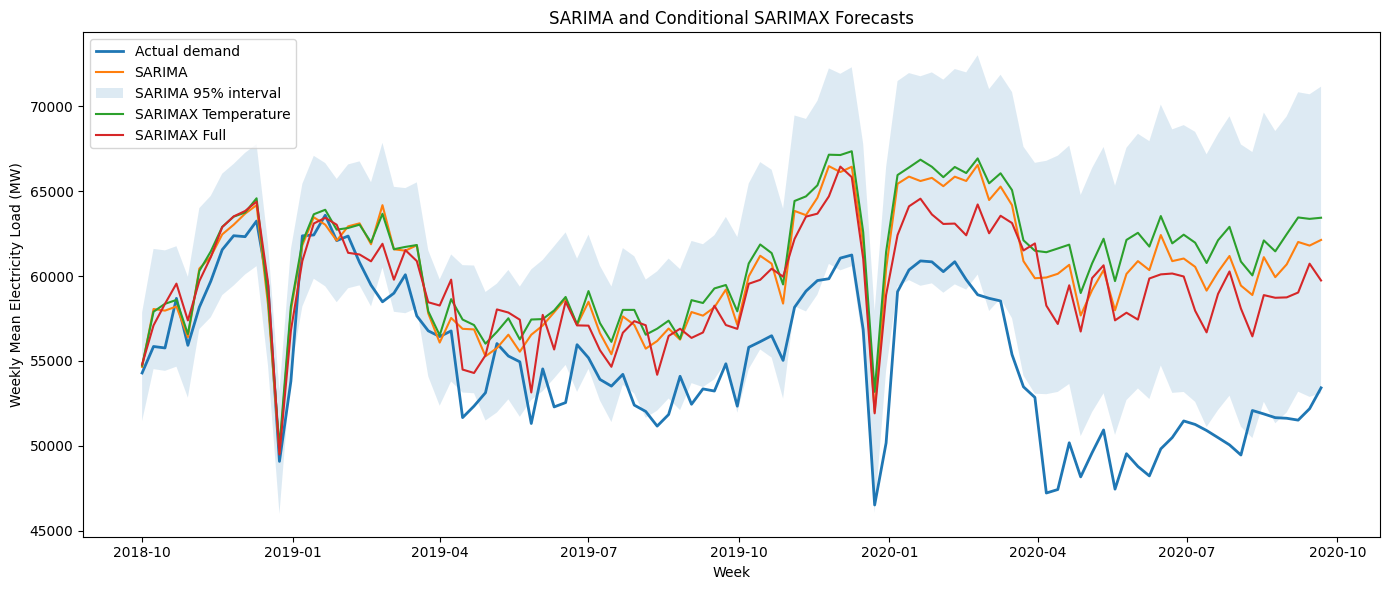

Observed future weather was supplied to SARIMAX, so these are conditional forecasts.


,Model,MAE,RMSE,sMAPE (%),MASE,RMSSE,Median AE,90th percentile AE,Bias,Error stability
2,SARIMAX Full,4344.4302,5285.8987,7.7441,3.2156,2.8766,3656.6209,8971.3428,4294.0230,3025.6697
0,SARIMA,5159.2834,6244.1333,9.0854,3.8187,3.3981,4981.6243,10355.8817,5095.9542,3534.2754
1,SARIMAX Temperature,5885.9655,7107.0061,10.2744,4.3565,3.8677,5609.2751,11578.2905,5863.5004,4002.3712


,Model,Coverage (%),Mean width,Interval score
0,SARIMA,55.7692,10715.3788,42626.5432
1,SARIMAX Temperature,47.1154,10908.6769,58593.6760
2,SARIMAX Full,100.0000,23668.2125,23668.2125


Cell 5 completed successfully.


In [ ]:
# ==============================================================
# CELL 5: SARIMA SEARCH, DIAGNOSTICS AND SARIMAX
# ==============================================================
# This cell:
# 1. Searches all 147 required p, d and q combinations.
# 2. Fits the minimum-AIC SARIMA.
# 3. Examines residual adequacy.
# 4. Fits temperature-only and full SARIMAX models.
#
# This cell may take several minutes.
# ==============================================================

statistical_names = [
    "SARIMA",
    "SARIMAX Temperature",
    "SARIMAX Full"
]

metrics_store[:] = [
    result
    for result in metrics_store
    if result["Model"] not in statistical_names
]

interval_store[:] = [
    result
    for result in interval_store
    if result["Model"] not in statistical_names
]


# ==============================================================
# 1. SEARCH ALL 147 REQUIRED ORDERS
# ==============================================================

seasonal_order = (
    0,
    1,
    1,
    SEASONAL_PERIOD
)

parameter_combinations = list(
    product(
        range(7),
        range(3),
        range(7)
    )
)

sarima_search_records = []

print(
    f"Testing {len(parameter_combinations)} "
    "SARIMA combinations..."
)

search_start = time.perf_counter()

for combination_number, order in enumerate(
    parameter_combinations,
    start=1
):

    try:

        candidate_model = SARIMAX(
            train_weekly,
            order=order,
            seasonal_order=seasonal_order,
            trend="n",
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        candidate_result = candidate_model.fit(
            disp=False,
            maxiter=150
        )

        sarima_search_records.append(
            {
                "order": order,
                "AIC": float(
                    candidate_result.aic
                ),
                "Converged": bool(
                    candidate_result
                    .mle_retvals
                    .get("converged", False)
                ),
                "Status": "Successful"
            }
        )

    except Exception as error:

        sarima_search_records.append(
            {
                "order": order,
                "AIC": np.nan,
                "Converged": False,
                "Status": str(error)[:150]
            }
        )

    if combination_number % 20 == 0:

        print(
            f"Completed {combination_number}/"
            f"{len(parameter_combinations)}"
        )

search_time = (
    time.perf_counter()
    - search_start
)

sarima_search = pd.DataFrame(
    sarima_search_records
)

successful_sarima = (
    sarima_search
    .dropna(subset=["AIC"])
    .sort_values("AIC")
    .reset_index(drop=True)
)

if successful_sarima.empty:
    raise RuntimeError(
        "No SARIMA candidate completed successfully."
    )

selected_order = tuple(
    successful_sarima.loc[
        0,
        "order"
    ]
)

print("\nTop SARIMA candidates:")
display(
    successful_sarima.head(10).round(3)
)

print(f"Selected order : {selected_order}")
print(f"Seasonal order : {seasonal_order}")
print(f"Search time    : {search_time:.2f} seconds")

sarima_search.to_csv(
    os.path.join(
        LOG_FOLDER,
        "sarima_search_log.csv"
    ),
    index=False
)


# ==============================================================
# 2. FIT SELECTED SARIMA
# ==============================================================

selected_sarima_model = SARIMAX(
    train_weekly,
    order=selected_order,
    seasonal_order=seasonal_order,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)

selected_sarima_result = (
    selected_sarima_model.fit(
        disp=False,
        maxiter=300
    )
)

sarima_output = (
    selected_sarima_result
    .get_forecast(
        steps=forecast_horizon
    )
)

sarima_forecast = pd.Series(
    sarima_output.predicted_mean.to_numpy(),
    index=forecast_index,
    name="SARIMA"
)

sarima_confidence = sarima_output.conf_int(
    alpha=0.05
)

sarima_lower = pd.Series(
    sarima_confidence.iloc[:, 0].to_numpy(),
    index=forecast_index
)

sarima_upper = pd.Series(
    sarima_confidence.iloc[:, 1].to_numpy(),
    index=forecast_index
)

forecast_store["SARIMA"] = sarima_forecast

metrics_store.append(
    evaluate_forecast(
        test_weekly,
        sarima_forecast,
        train_weekly,
        "SARIMA"
    )
)

interval_store.append(
    evaluate_intervals(
        test_weekly,
        sarima_lower,
        sarima_upper,
        "SARIMA"
    )
)


# ==============================================================
# 3. RESIDUAL DIAGNOSTICS
# ==============================================================

burn_in = int(
    getattr(
        selected_sarima_result,
        "loglikelihood_burn",
        0
    )
)

sarima_residuals = (
    pd.Series(
        selected_sarima_result.resid
    )
    .iloc[burn_in:]
    .dropna()
)

ljung_box_results = acorr_ljungbox(
    sarima_residuals,
    lags=[12, 26, 52],
    return_df=True
)

print("Ljung-Box test:")
display(
    ljung_box_results.round(4)
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

axes[0].plot(
    sarima_residuals.index,
    sarima_residuals.values
)

axes[0].axhline(
    0,
    linestyle="--"
)

axes[0].set_title(
    "SARIMA Residual Sequence"
)

axes[0].set_xlabel(
    "Training Observation"
)

axes[0].set_ylabel("Residual")

axes[1].hist(
    sarima_residuals,
    bins=25
)

axes[1].set_title(
    "SARIMA Residual Distribution"
)

axes[1].set_xlabel("Residual")

plot_acf(
    sarima_residuals,
    lags=52,
    ax=axes[2]
)

axes[2].set_title(
    "SARIMA Residual ACF"
)

save_figure(
    "sarima_residual_diagnostics",
    fig
)

plt.show()


# ==============================================================
# 4. TEMPERATURE-ONLY SARIMAX
# ==============================================================

temperature_columns = [
    "temp_mean"
]

temperature_scaler = StandardScaler()

temperature_train_scaled = pd.DataFrame(
    temperature_scaler.fit_transform(
        train_exog[
            temperature_columns
        ]
    ),
    index=train_exog.index,
    columns=temperature_columns
)

temperature_test_scaled = pd.DataFrame(
    temperature_scaler.transform(
        test_exog[
            temperature_columns
        ]
    ),
    index=test_exog.index,
    columns=temperature_columns
)

sarimax_temperature_model = SARIMAX(
    train_weekly,
    exog=temperature_train_scaled,
    order=selected_order,
    seasonal_order=seasonal_order,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_temperature_result = (
    sarimax_temperature_model.fit(
        disp=False,
        maxiter=300
    )
)

sarimax_temperature_output = (
    sarimax_temperature_result
    .get_forecast(
        steps=forecast_horizon,
        exog=temperature_test_scaled
    )
)

sarimax_temperature_forecast = pd.Series(
    sarimax_temperature_output
    .predicted_mean
    .to_numpy(),
    index=forecast_index,
    name="SARIMAX Temperature"
)

temperature_confidence = (
    sarimax_temperature_output
    .conf_int(alpha=0.05)
)

temperature_lower = pd.Series(
    temperature_confidence.iloc[:, 0].to_numpy(),
    index=forecast_index
)

temperature_upper = pd.Series(
    temperature_confidence.iloc[:, 1].to_numpy(),
    index=forecast_index
)

forecast_store[
    "SARIMAX Temperature"
] = sarimax_temperature_forecast

metrics_store.append(
    evaluate_forecast(
        test_weekly,
        sarimax_temperature_forecast,
        train_weekly,
        "SARIMAX Temperature"
    )
)

interval_store.append(
    evaluate_intervals(
        test_weekly,
        temperature_lower,
        temperature_upper,
        "SARIMAX Temperature"
    )
)


# ==============================================================
# 5. FULL SARIMAX
# ==============================================================

full_exogenous_columns = [
    "temp_mean",
    "hdd",
    "cdd",
    "holiday_days",
    "working_days",
    "christmas_new_year",
    "week_sin",
    "week_cos"
]

full_scaler = StandardScaler()

full_train_scaled = pd.DataFrame(
    full_scaler.fit_transform(
        train_exog[
            full_exogenous_columns
        ]
    ),
    index=train_exog.index,
    columns=full_exogenous_columns
)

full_test_scaled = pd.DataFrame(
    full_scaler.transform(
        test_exog[
            full_exogenous_columns
        ]
    ),
    index=test_exog.index,
    columns=full_exogenous_columns
)

sarimax_full_model = SARIMAX(
    train_weekly,
    exog=full_train_scaled,
    order=selected_order,
    seasonal_order=seasonal_order,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_full_result = (
    sarimax_full_model.fit(
        disp=False,
        maxiter=300
    )
)

sarimax_full_output = (
    sarimax_full_result
    .get_forecast(
        steps=forecast_horizon,
        exog=full_test_scaled
    )
)

sarimax_full_forecast = pd.Series(
    sarimax_full_output
    .predicted_mean
    .to_numpy(),
    index=forecast_index,
    name="SARIMAX Full"
)

full_confidence = sarimax_full_output.conf_int(
    alpha=0.05
)

full_lower = pd.Series(
    full_confidence.iloc[:, 0].to_numpy(),
    index=forecast_index
)

full_upper = pd.Series(
    full_confidence.iloc[:, 1].to_numpy(),
    index=forecast_index
)

forecast_store[
    "SARIMAX Full"
] = sarimax_full_forecast

metrics_store.append(
    evaluate_forecast(
        test_weekly,
        sarimax_full_forecast,
        train_weekly,
        "SARIMAX Full"
    )
)

interval_store.append(
    evaluate_intervals(
        test_weekly,
        full_lower,
        full_upper,
        "SARIMAX Full"
    )
)


# ==============================================================
# PLOT: SARIMA AND SARIMAX
# ==============================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    test_weekly.index,
    test_weekly.values,
    linewidth=2,
    label="Actual demand"
)

ax.plot(
    sarima_forecast.index,
    sarima_forecast.values,
    label="SARIMA"
)

ax.fill_between(
    forecast_index,
    sarima_lower.values,
    sarima_upper.values,
    alpha=0.15,
    label="SARIMA 95% interval"
)

ax.plot(
    sarimax_temperature_forecast.index,
    sarimax_temperature_forecast.values,
    label="SARIMAX Temperature"
)

ax.plot(
    sarimax_full_forecast.index,
    sarimax_full_forecast.values,
    label="SARIMAX Full"
)

ax.set_title(
    "SARIMA and Conditional SARIMAX Forecasts"
)

ax.set_xlabel("Week")
ax.set_ylabel(
    "Weekly Mean Electricity Load (MW)"
)

ax.legend()

save_figure(
    "sarima_sarimax_forecasts",
    fig
)

plt.show()


# ==============================================================
# DISPLAY RESULTS
# ==============================================================

statistical_metrics = pd.DataFrame(
    [
        result
        for result in metrics_store
        if result["Model"] in statistical_names
    ]
).sort_values("RMSE")

interval_metrics = pd.DataFrame(
    interval_store
)

print(
    "Observed future weather was supplied to SARIMAX, "
    "so these are conditional forecasts."
)

display(
    statistical_metrics.round(4)
)

display(
    interval_metrics.round(4)
)


# ==============================================================
# SAVE MODELS AND SCALERS
# ==============================================================

selected_sarima_result.save(
    os.path.join(
        MODEL_FOLDER,
        "selected_sarima.pkl"
    )
)

sarimax_temperature_result.save(
    os.path.join(
        MODEL_FOLDER,
        "sarimax_temperature.pkl"
    )
)

sarimax_full_result.save(
    os.path.join(
        MODEL_FOLDER,
        "sarimax_full.pkl"
    )
)

joblib.dump(
    temperature_scaler,
    os.path.join(
        MODEL_FOLDER,
        "temperature_scaler.joblib"
    )
)

joblib.dump(
    full_scaler,
    os.path.join(
        MODEL_FOLDER,
        "full_sarimax_scaler.joblib"
    )
)

print("Cell 5 completed successfully.")

Training rows: 143
Predictors   : 19
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best AdaBoost parameters:
{'n_estimators': 200, 'loss': 'exponential', 'learning_rate': 0.2, 'estimator__min_samples_leaf': 6, 'estimator__max_depth': 2}
Leakage check passed: actual test demand was not inserted into recursive lag features.


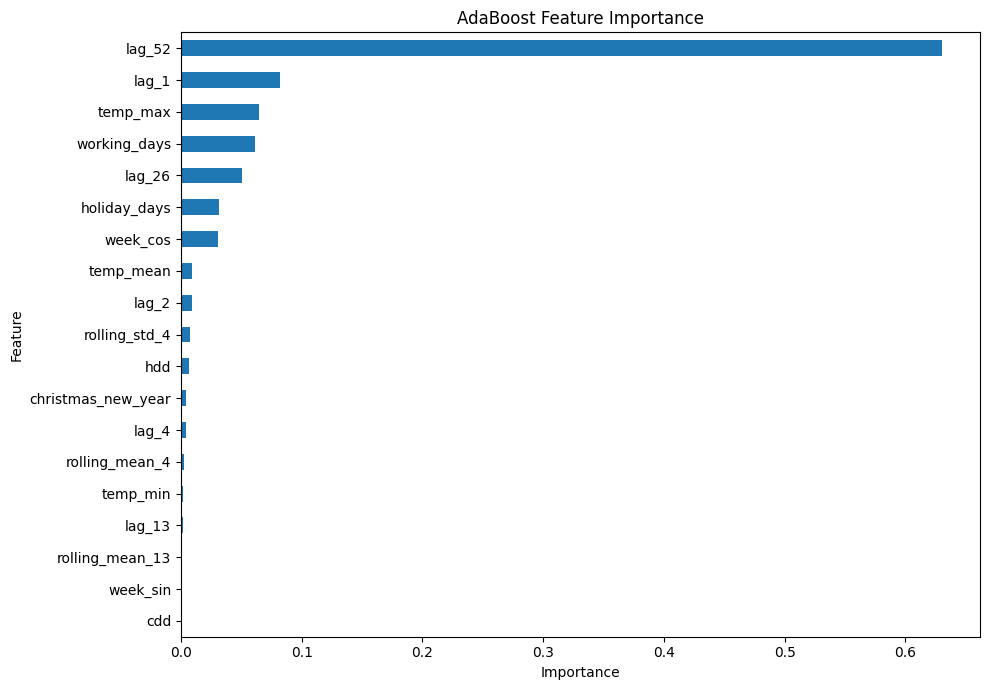

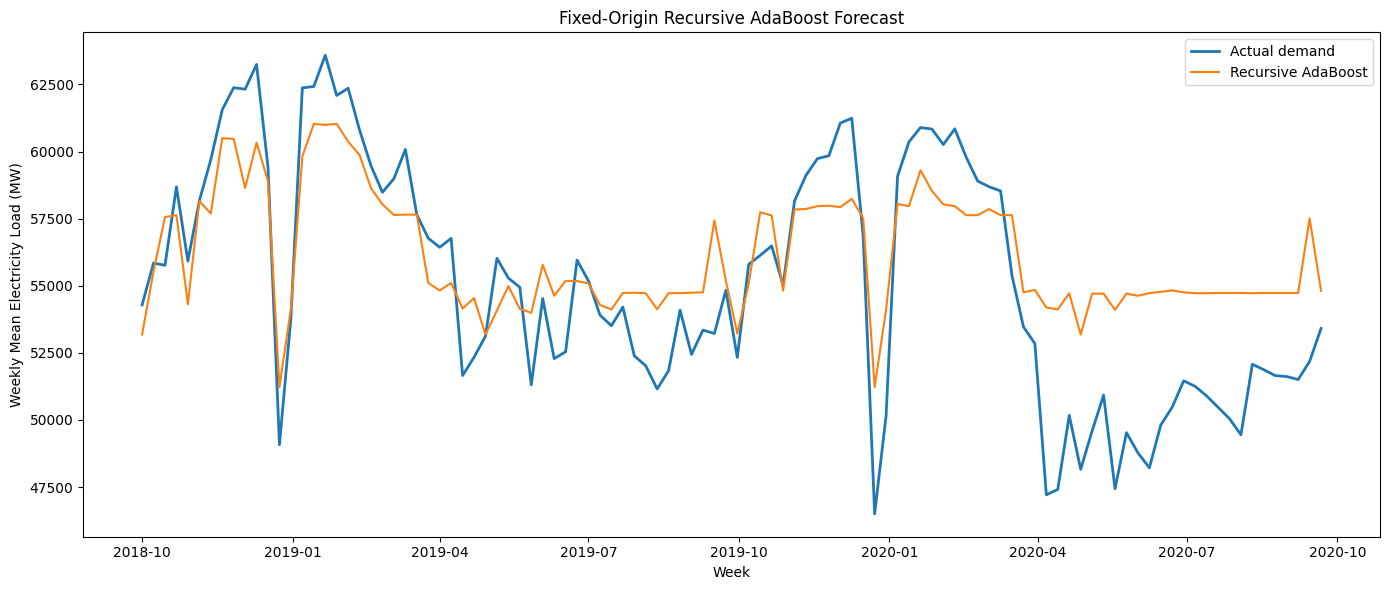

,Model,MAE,RMSE,sMAPE (%),MASE,RMSSE,Median AE,90th percentile AE,Bias,Error stability
0,AdaBoost,2311.152,2849.6594,4.2559,1.7106,1.5508,2003.9096,4887.5916,956.7092,1675.1468


Observed future weather was used, so the AdaBoost forecast is conditional on that weather path.
Cell 6 completed successfully.


In [ ]:
# ==============================================================
# CELL 6: ADABOOST FEATURE-BASED FORECAST
# ==============================================================
# This cell:
# 1. Creates leakage-safe lag and rolling features.
# 2. Tunes AdaBoost with TimeSeriesSplit.
# 3. Produces a recursive 104-week forecast.
# 4. Displays feature importance and the final forecast.
# ==============================================================

metrics_store[:] = [
    result
    for result in metrics_store
    if result["Model"] != "AdaBoost"
]


# ==============================================================
# FEATURE SETTINGS
# ==============================================================

ADABOOST_LAGS = [
    1,
    2,
    4,
    13,
    26,
    52
]

ADABOOST_EXOGENOUS_COLUMNS = [
    "temp_mean",
    "temp_min",
    "temp_max",
    "hdd",
    "cdd",
    "holiday_days",
    "working_days",
    "christmas_new_year",
    "week_sin",
    "week_cos"
]


# ==============================================================
# CREATE TRAINING FEATURES
# ==============================================================

def create_adaboost_training_table(
    target_series,
    exogenous_data
):
    """
    Create leakage-safe training features.

    Lagged and rolling predictors use only earlier demand.
    """

    feature_table = pd.DataFrame(
        index=target_series.index
    )

    for lag in ADABOOST_LAGS:

        feature_table[
            f"lag_{lag}"
        ] = target_series.shift(lag)

    # Shift before rolling so the current target is excluded.
    shifted_target = target_series.shift(1)

    feature_table["rolling_mean_4"] = (
        shifted_target
        .rolling(4)
        .mean()
    )

    feature_table["rolling_mean_13"] = (
        shifted_target
        .rolling(13)
        .mean()
    )

    feature_table["rolling_std_4"] = (
        shifted_target
        .rolling(4)
        .std()
    )

    feature_table = feature_table.join(
        exogenous_data[
            ADABOOST_EXOGENOUS_COLUMNS
        ]
    )

    feature_table["target"] = target_series

    return feature_table.dropna()


adaboost_training_table = (
    create_adaboost_training_table(
        train_weekly,
        train_exog
    )
)

X_adaboost_train = (
    adaboost_training_table
    .drop(columns="target")
)

y_adaboost_train = (
    adaboost_training_table["target"]
)

adaboost_feature_columns = (
    X_adaboost_train
    .columns
    .tolist()
)

print(
    f"Training rows: {len(X_adaboost_train)}"
)

print(
    f"Predictors   : {len(adaboost_feature_columns)}"
)


# ==============================================================
# DEFINE ADABOOST
# ==============================================================

base_tree = DecisionTreeRegressor(
    random_state=RANDOM_SEED
)

# Compatibility with different scikit-learn versions.
try:

    adaboost_model = AdaBoostRegressor(
        estimator=base_tree,
        random_state=RANDOM_SEED
    )

    tree_parameter_prefix = "estimator__"

except TypeError:

    adaboost_model = AdaBoostRegressor(
        base_estimator=base_tree,
        random_state=RANDOM_SEED
    )

    tree_parameter_prefix = "base_estimator__"


parameter_distribution = {
    "n_estimators": [
        50,
        100,
        150,
        200,
        300
    ],
    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.10,
        0.20
    ],
    "loss": [
        "linear",
        "square",
        "exponential"
    ],
    f"{tree_parameter_prefix}max_depth": [
        1,
        2,
        3,
        4
    ],
    f"{tree_parameter_prefix}min_samples_leaf": [
        2,
        4,
        6,
        8
    ]
}

time_series_cv = TimeSeriesSplit(
    n_splits=5
)

adaboost_search = RandomizedSearchCV(
    estimator=adaboost_model,
    param_distributions=parameter_distribution,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=time_series_cv,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1,
    error_score=np.nan
)

adaboost_search.fit(
    X_adaboost_train,
    y_adaboost_train
)

best_adaboost = (
    adaboost_search
    .best_estimator_
)

print("Best AdaBoost parameters:")
print(adaboost_search.best_params_)


# ==============================================================
# CREATE ONE RECURSIVE FEATURE ROW
# ==============================================================

def create_recursive_adaboost_row(
    history,
    forecast_date,
    exogenous_data
):
    """
    Create predictors for one future week.

    History contains training observations and earlier predictions.
    It does not contain future actual test demand.
    """

    history = (
        pd.Series(history)
        .sort_index()
    )

    row = {}

    for lag in ADABOOST_LAGS:

        row[f"lag_{lag}"] = (
            history.iloc[-lag]
        )

    row["rolling_mean_4"] = (
        history.iloc[-4:].mean()
    )

    row["rolling_mean_13"] = (
        history.iloc[-13:].mean()
    )

    row["rolling_std_4"] = (
        history.iloc[-4:].std()
    )

    for column in ADABOOST_EXOGENOUS_COLUMNS:

        row[column] = exogenous_data.loc[
            forecast_date,
            column
        ]

    row_frame = pd.DataFrame(
        [row],
        index=[forecast_date]
    )

    return row_frame[
        adaboost_feature_columns
    ]


# ==============================================================
# RECURSIVE FIXED-ORIGIN FORECAST
# ==============================================================

recursive_history = train_weekly.copy()
adaboost_predictions = []

for forecast_date in forecast_index:

    feature_row = create_recursive_adaboost_row(
        history=recursive_history,
        forecast_date=forecast_date,
        exogenous_data=weekly_exog
    )

    prediction = float(
        best_adaboost.predict(
            feature_row
        )[0]
    )

    adaboost_predictions.append(
        prediction
    )

    # Append prediction, not actual test demand.
    recursive_history.loc[
        forecast_date
    ] = prediction

adaboost_forecast = pd.Series(
    adaboost_predictions,
    index=forecast_index,
    name="AdaBoost"
)

forecast_store[
    "AdaBoost"
] = adaboost_forecast

metrics_store.append(
    evaluate_forecast(
        test_weekly,
        adaboost_forecast,
        train_weekly,
        "AdaBoost"
    )
)

print(
    "Leakage check passed: actual test demand was not "
    "inserted into recursive lag features."
)


# ==============================================================
# PLOT 1: FEATURE IMPORTANCE
# ==============================================================

feature_importance = pd.Series(
    best_adaboost.feature_importances_,
    index=adaboost_feature_columns
).sort_values(
    ascending=False
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

feature_importance.sort_values().plot.barh(
    ax=ax
)

ax.set_title(
    "AdaBoost Feature Importance"
)

ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

save_figure(
    "adaboost_feature_importance",
    fig
)

plt.show()


# ==============================================================
# PLOT 2: RECURSIVE ADABOOST FORECAST
# ==============================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    test_weekly.index,
    test_weekly.values,
    linewidth=2,
    label="Actual demand"
)

ax.plot(
    adaboost_forecast.index,
    adaboost_forecast.values,
    label="Recursive AdaBoost"
)

ax.set_title(
    "Fixed-Origin Recursive AdaBoost Forecast"
)

ax.set_xlabel("Week")
ax.set_ylabel(
    "Weekly Mean Electricity Load (MW)"
)

ax.legend()

save_figure(
    "adaboost_recursive_forecast",
    fig
)

plt.show()


# ==============================================================
# SAVE MODEL AND RESULTS
# ==============================================================

joblib.dump(
    best_adaboost,
    os.path.join(
        MODEL_FOLDER,
        "best_adaboost.joblib"
    )
)

feature_importance.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "adaboost_feature_importance.csv"
    )
)

adaboost_metric = pd.DataFrame(
    [
        result
        for result in metrics_store
        if result["Model"] == "AdaBoost"
    ]
)

display(
    adaboost_metric.round(4)
)

print(
    "Observed future weather was used, so the AdaBoost "
    "forecast is conditional on that weather path."
)

print("Cell 6 completed successfully.")

Training sequences  : (1082, 168, 1)
Validation sequences: (246, 168, 1)
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.9805 - val_loss: 0.9242
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8940 - val_loss: 0.8925
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6819 - val_loss: 1.0276
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5377 - val_loss: 1.1074
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4836 - val_loss: 1.1084
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4606 - val_loss: 1.0937
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.9662 - val_loss: 0.9139
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7350 - val_loss: 1.0965
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5148 - val_loss: 1.0756
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4604 - val_loss: 1.0827
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4381 - val_loss:

,Architecture,Units,Dropout,Validation loss,Best epoch
0,LSTM-32,32,0.1,0.892463,2
1,LSTM-64,64,0.2,0.913869,1


Epoch 1/2
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.9733
Epoch 2/2
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8251


,Model,MAE,RMSE,sMAPE (%),Bias
0,LSTM Hourly,7706.4194,9223.3408,14.0929,2124.0713


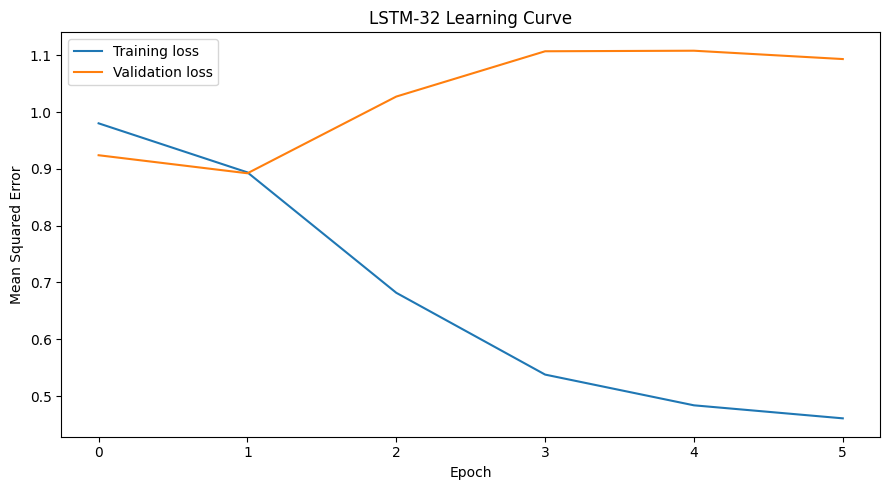

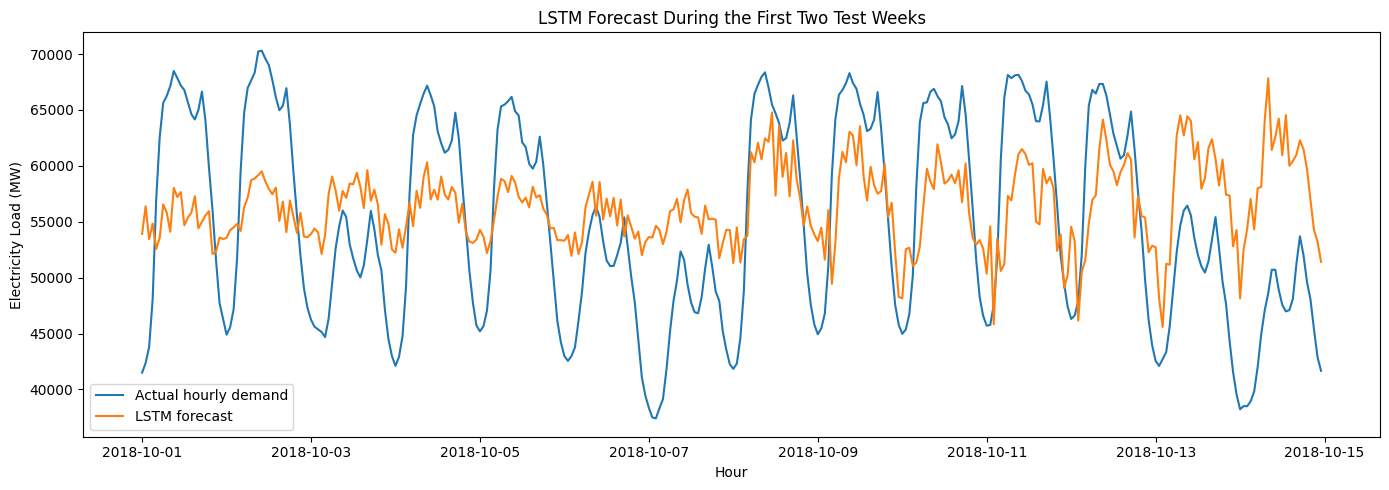

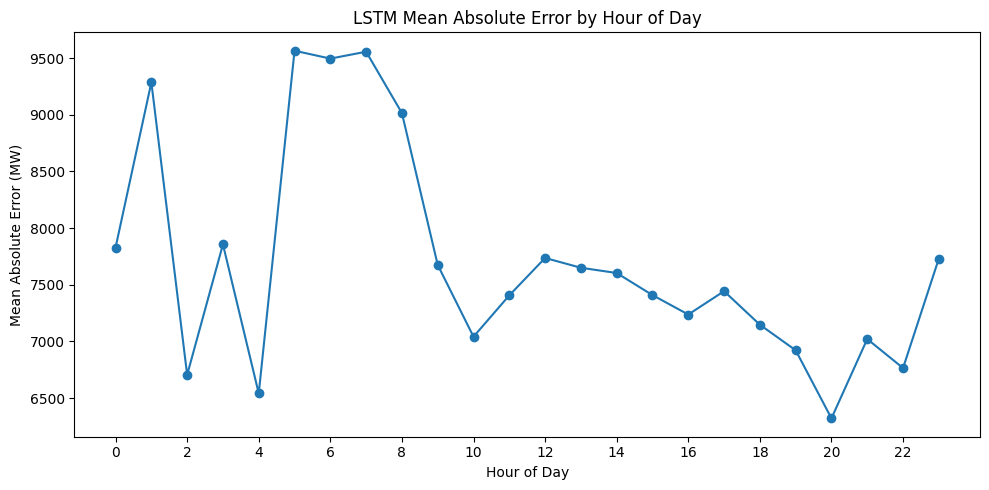

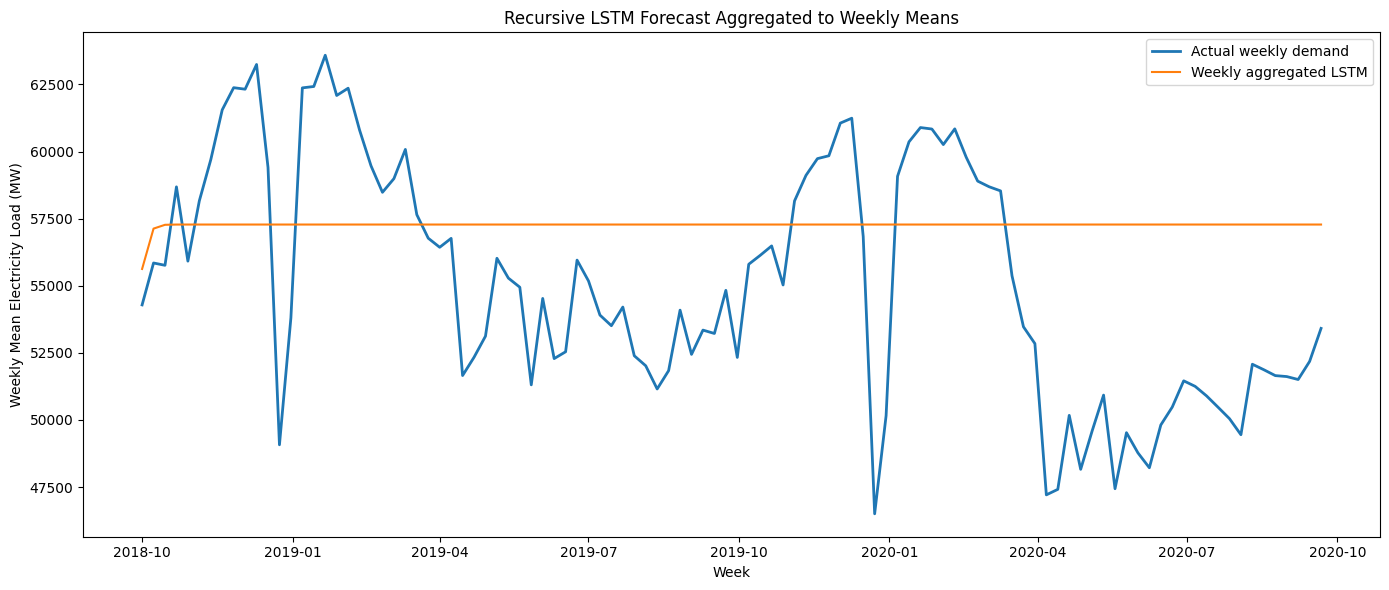

Cell 7 completed successfully.


In [ ]:
# ==============================================================
# CELL 7: HOURLY LSTM
# ==============================================================
# This cell:
# 1. Fits scaling on hourly training data only.
# 2. Creates 168-hour input and output sequences.
# 3. Compares 32-unit and 64-unit LSTM models.
# 4. Generates recursive weekly blocks for two years.
# 5. Displays the learning curve, hourly forecast sample,
#    hourly error pattern and weekly aggregated forecast.
# ==============================================================

metrics_store[:] = [
    result
    for result in metrics_store
    if result["Model"] != "LSTM"
]

INPUT_HOURS = 168
OUTPUT_HOURS = 168
SEQUENCE_STRIDE = 24

MAX_EPOCHS = 20
BATCH_SIZE = 64


# ==============================================================
# 1. TRAINING-ONLY SCALING
# ==============================================================

lstm_scaler = StandardScaler()

hourly_train_scaled = (
    lstm_scaler
    .fit_transform(
        hourly_train
        .to_numpy()
        .reshape(-1, 1)
    )
)


# ==============================================================
# 2. CREATE SEQUENCES
# ==============================================================

def create_lstm_sequences(
    scaled_values,
    input_hours=168,
    output_hours=168,
    stride=24
):
    """
    Create fixed-length input and output sequences.
    """

    X_sequences = []
    y_sequences = []

    final_start = (
        len(scaled_values)
        - input_hours
        - output_hours
    )

    for start in range(
        0,
        final_start + 1,
        stride
    ):

        input_end = (
            start + input_hours
        )

        output_end = (
            input_end + output_hours
        )

        X_sequences.append(
            scaled_values[
                start:input_end
            ]
        )

        y_sequences.append(
            scaled_values[
                input_end:output_end,
                0
            ]
        )

    return (
        np.asarray(X_sequences),
        np.asarray(y_sequences)
    )


# ==============================================================
# 3. CHRONOLOGICAL TRAINING AND VALIDATION SPLIT
# ==============================================================

raw_split_position = int(
    len(hourly_train_scaled) * 0.80
)

# Purge gap prevents training and validation windows overlapping.
purge_gap = (
    INPUT_HOURS + OUTPUT_HOURS
)

training_raw = hourly_train_scaled[
    :raw_split_position
]

validation_raw = hourly_train_scaled[
    raw_split_position + purge_gap:
]

X_lstm_train, y_lstm_train = (
    create_lstm_sequences(
        training_raw,
        INPUT_HOURS,
        OUTPUT_HOURS,
        SEQUENCE_STRIDE
    )
)

X_lstm_validation, y_lstm_validation = (
    create_lstm_sequences(
        validation_raw,
        INPUT_HOURS,
        OUTPUT_HOURS,
        SEQUENCE_STRIDE
    )
)

print(
    f"Training sequences  : {X_lstm_train.shape}"
)

print(
    f"Validation sequences: {X_lstm_validation.shape}"
)


# ==============================================================
# 4. BUILD LSTM FUNCTION
# ==============================================================

def build_lstm_model(
    units,
    dropout_rate
):
    """
    Build a compact many-output LSTM model.
    """

    model = Sequential(
        [
            Input(
                shape=(INPUT_HOURS, 1)
            ),
            LSTM(units),
            Dropout(dropout_rate),
            Dense(OUTPUT_HOURS)
        ]
    )

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="mse"
    )

    return model


architectures = [
    {
        "Architecture": "LSTM-32",
        "Units": 32,
        "Dropout": 0.10
    },
    {
        "Architecture": "LSTM-64",
        "Units": 64,
        "Dropout": 0.20
    }
]


# ==============================================================
# 5. COMPARE ARCHITECTURES
# ==============================================================

architecture_records = []
training_histories = {}

for configuration in architectures:

    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_SEED)

    candidate_model = build_lstm_model(
        units=configuration["Units"],
        dropout_rate=configuration["Dropout"]
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )

    history = candidate_model.fit(
        X_lstm_train,
        y_lstm_train,
        validation_data=(
            X_lstm_validation,
            y_lstm_validation
        ),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=False,
        callbacks=[early_stopping],
        verbose=1
    )

    best_validation_loss = min(
        history.history["val_loss"]
    )

    best_epoch = int(
        np.argmin(
            history.history["val_loss"]
        ) + 1
    )

    architecture_records.append(
        {
            "Architecture": configuration[
                "Architecture"
            ],
            "Units": configuration["Units"],
            "Dropout": configuration["Dropout"],
            "Validation loss": (
                best_validation_loss
            ),
            "Best epoch": best_epoch
        }
    )

    training_histories[
        configuration["Architecture"]
    ] = history.history


architecture_results = pd.DataFrame(
    architecture_records
).sort_values(
    "Validation loss"
)

display(
    architecture_results.round(6)
)


# ==============================================================
# 6. REFIT SELECTED MODEL ON ALL TRAINING SEQUENCES
# ==============================================================

best_architecture_name = (
    architecture_results
    .iloc[0]["Architecture"]
)

selected_configuration = next(
    configuration
    for configuration in architectures
    if configuration["Architecture"]
    == best_architecture_name
)

selected_epochs = int(
    architecture_results
    .iloc[0]["Best epoch"]
)

X_lstm_full, y_lstm_full = (
    create_lstm_sequences(
        hourly_train_scaled,
        INPUT_HOURS,
        OUTPUT_HOURS,
        SEQUENCE_STRIDE
    )
)

tf.keras.backend.clear_session()
tf.random.set_seed(RANDOM_SEED)

final_lstm_model = build_lstm_model(
    units=selected_configuration["Units"],
    dropout_rate=selected_configuration["Dropout"]
)

final_lstm_model.fit(
    X_lstm_full,
    y_lstm_full,
    epochs=selected_epochs,
    batch_size=BATCH_SIZE,
    shuffle=False,
    verbose=1
)


# ==============================================================
# 7. RECURSIVE TWO-YEAR HOURLY FORECAST
# ==============================================================

current_window = hourly_train_scaled[
    -INPUT_HOURS:
].reshape(
    1,
    INPUT_HOURS,
    1
)

lstm_scaled_predictions = []

for week_number in range(TEST_WEEKS):

    predicted_week = (
        final_lstm_model
        .predict(
            current_window,
            verbose=0
        )
        .reshape(
            OUTPUT_HOURS,
            1
        )
    )

    lstm_scaled_predictions.extend(
        predicted_week[:, 0]
    )

    # Predicted week becomes the next 168-hour input.
    current_window = predicted_week.reshape(
        1,
        INPUT_HOURS,
        1
    )


lstm_hourly_values = (
    lstm_scaler
    .inverse_transform(
        np.asarray(
            lstm_scaled_predictions
        ).reshape(-1, 1)
    )
    .ravel()
)

expected_test_hours = (
    TEST_WEEKS * OUTPUT_HOURS
)

hourly_test_aligned = hourly_test.iloc[
    :expected_test_hours
].copy()

if len(hourly_test_aligned) != len(
    lstm_hourly_values
):
    raise ValueError(
        "LSTM prediction length does not match the test period."
    )

lstm_hourly_forecast = pd.Series(
    lstm_hourly_values,
    index=hourly_test_aligned.index,
    name="LSTM hourly forecast"
)


# ==============================================================
# 8. HOURLY METRICS
# ==============================================================

hourly_actual = (
    hourly_test_aligned
    .to_numpy()
)

hourly_predicted = (
    lstm_hourly_forecast
    .to_numpy()
)

hourly_lstm_metrics = pd.DataFrame(
    [
        {
            "Model": "LSTM Hourly",
            "MAE": mean_absolute_error(
                hourly_actual,
                hourly_predicted
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    hourly_actual,
                    hourly_predicted
                )
            ),
            "sMAPE (%)": smape(
                hourly_actual,
                hourly_predicted
            ),
            "Bias": np.mean(
                hourly_predicted
                - hourly_actual
            )
        }
    ]
)

display(
    hourly_lstm_metrics.round(4)
)


# ==============================================================
# 9. AGGREGATE LSTM FORECAST TO WEEKLY MEANS
# ==============================================================

lstm_hourly_frame = pd.DataFrame(
    {
        "Actual": hourly_test_aligned,
        "Prediction": lstm_hourly_forecast
    }
)

lstm_hourly_frame["week_start"] = (
    lstm_hourly_frame.index
    .to_period("W-SUN")
    .start_time
)

lstm_weekly_forecast = (
    lstm_hourly_frame
    .groupby("week_start")[
        "Prediction"
    ]
    .mean()
    .reindex(test_weekly.index)
)

lstm_weekly_forecast.name = "LSTM"

if lstm_weekly_forecast.isna().any():
    raise ValueError(
        "The weekly LSTM forecast contains missing values."
    )

forecast_store["LSTM"] = (
    lstm_weekly_forecast
)

metrics_store.append(
    evaluate_forecast(
        test_weekly,
        lstm_weekly_forecast,
        train_weekly,
        "LSTM"
    )
)


# ==============================================================
# PLOT 1: LEARNING CURVE
# ==============================================================

selected_history = training_histories[
    best_architecture_name
]

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    selected_history["loss"],
    label="Training loss"
)

ax.plot(
    selected_history["val_loss"],
    label="Validation loss"
)

ax.set_title(
    f"{best_architecture_name} Learning Curve"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Squared Error")
ax.legend()

save_figure(
    "selected_lstm_learning_curve",
    fig
)

plt.show()


# ==============================================================
# PLOT 2: FIRST TWO WEEKS OF HOURLY FORECAST
# ==============================================================

sample_hours = 24 * 14

fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    hourly_test_aligned.index[:sample_hours],
    hourly_test_aligned.iloc[:sample_hours],
    label="Actual hourly demand"
)

ax.plot(
    lstm_hourly_forecast.index[:sample_hours],
    lstm_hourly_forecast.iloc[:sample_hours],
    label="LSTM forecast"
)

ax.set_title(
    "LSTM Forecast During the First Two Test Weeks"
)

ax.set_xlabel("Hour")
ax.set_ylabel("Electricity Load (MW)")
ax.legend()

save_figure(
    "lstm_hourly_forecast_sample",
    fig
)

plt.show()


# ==============================================================
# PLOT 3: LSTM ERROR BY HOUR OF DAY
# ==============================================================

hourly_error_frame = pd.DataFrame(
    {
        "Absolute error": np.abs(
            hourly_predicted
            - hourly_actual
        )
    },
    index=hourly_test_aligned.index
)

hourly_error_frame["Hour"] = (
    hourly_error_frame.index.hour
)

mae_by_hour = (
    hourly_error_frame
    .groupby("Hour")[
        "Absolute error"
    ]
    .mean()
)

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    mae_by_hour.index,
    mae_by_hour.values,
    marker="o"
)

ax.set_title(
    "LSTM Mean Absolute Error by Hour of Day"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean Absolute Error (MW)")

ax.set_xticks(
    range(0, 24, 2)
)

save_figure(
    "lstm_error_by_hour",
    fig
)

plt.show()


# ==============================================================
# PLOT 4: WEEKLY AGGREGATED LSTM FORECAST
# ==============================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    test_weekly.index,
    test_weekly.values,
    linewidth=2,
    label="Actual weekly demand"
)

ax.plot(
    lstm_weekly_forecast.index,
    lstm_weekly_forecast.values,
    label="Weekly aggregated LSTM"
)

ax.set_title(
    "Recursive LSTM Forecast Aggregated to Weekly Means"
)

ax.set_xlabel("Week")
ax.set_ylabel(
    "Weekly Mean Electricity Load (MW)"
)

ax.legend()

save_figure(
    "lstm_weekly_forecast",
    fig
)

plt.show()


# ==============================================================
# SAVE MODEL AND RESULTS
# ==============================================================

final_lstm_model.save(
    os.path.join(
        MODEL_FOLDER,
        "final_lstm_model.keras"
    )
)

joblib.dump(
    lstm_scaler,
    os.path.join(
        MODEL_FOLDER,
        "lstm_scaler.joblib"
    )
)

architecture_results.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "lstm_architecture_results.csv"
    ),
    index=False
)

hourly_lstm_metrics.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "hourly_lstm_metrics.csv"
    ),
    index=False
)

print("Cell 7 completed successfully.")

In [ ]:
# ==============================================================
# CELL 8: MODEL-REFRESH POLICY EXPERIMENT
# ==============================================================
# Models:
# - Seasonal Naive
# - SARIMA
# - AdaBoost
#
# Policies:
# - Frozen
# - Annual
# - Semiannual
# - Quarterly
#
# At each refresh, only observations already available before the
# new forecast segment are used.
# ==============================================================


# ==============================================================
# SEGMENT FORECAST FUNCTIONS
# ==============================================================

def seasonal_naive_segment_forecast(
    available_history,
    segment_dates
):
    """
    Forecast one segment using annual seasonal persistence.
    """

    working_history = (
        available_history.copy()
    )

    predictions = []

    for date in segment_dates:

        prediction = float(
            working_history.iloc[
                -SEASONAL_PERIOD
            ]
        )

        predictions.append(
            prediction
        )

        working_history.loc[
            date
        ] = prediction

    return pd.Series(
        predictions,
        index=segment_dates
    )


def sarima_segment_forecast(
    available_history,
    segment_dates
):
    """
    Refit the selected SARIMA order and forecast one segment.
    """

    model = SARIMAX(
        available_history,
        order=selected_order,
        seasonal_order=seasonal_order,
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(
        disp=False,
        maxiter=300
    )

    output = result.get_forecast(
        steps=len(segment_dates)
    )

    return pd.Series(
        output.predicted_mean.to_numpy(),
        index=segment_dates
    )


def adaboost_segment_forecast(
    available_history,
    segment_dates
):
    """
    Refit AdaBoost using available observations, then forecast
    recursively until the next refresh.
    """

    available_exog = weekly_exog.loc[
        available_history.index
    ]

    refreshed_training_table = (
        create_adaboost_training_table(
            available_history,
            available_exog
        )
    )

    X_refreshed = refreshed_training_table[
        adaboost_feature_columns
    ]

    y_refreshed = refreshed_training_table[
        "target"
    ]

    refreshed_model = clone(
        best_adaboost
    )

    refreshed_model.fit(
        X_refreshed,
        y_refreshed
    )

    recursive_history = (
        available_history.copy()
    )

    predictions = []

    for date in segment_dates:

        feature_row = (
            create_recursive_adaboost_row(
                recursive_history,
                date,
                weekly_exog
            )
        )

        prediction = float(
            refreshed_model.predict(
                feature_row
            )[0]
        )

        predictions.append(
            prediction
        )

        recursive_history.loc[
            date
        ] = prediction

    return pd.Series(
        predictions,
        index=segment_dates
    )


refresh_model_functions = {
    "Seasonal Naive": (
        seasonal_naive_segment_forecast
    ),
    "SARIMA": (
        sarima_segment_forecast
    ),
    "AdaBoost": (
        adaboost_segment_forecast
    )
}


# ==============================================================
# RUN ALL MODELS AND POLICIES
# ==============================================================

refresh_prediction_records = []
refresh_run_records = []

for model_name, model_function in (
    refresh_model_functions.items()
):

    print(
        f"\nRunning refresh experiment for {model_name}"
    )

    for policy_name, refresh_interval in (
        REFRESH_POLICIES.items()
    ):

        schedule = make_refresh_schedule(
            len(test_weekly),
            refresh_interval
        )

        for segment_number, segment_start in enumerate(
            schedule
        ):

            if segment_number < len(schedule) - 1:

                segment_end = schedule[
                    segment_number + 1
                ]

            else:

                segment_end = len(
                    test_weekly
                )

            segment_dates = test_weekly.index[
                segment_start:segment_end
            ]

            refresh_date = segment_dates[0]

            # Only demand observed before the refresh date is used.
            available_history = weekly_load.loc[
                weekly_load.index < refresh_date
            ].copy()

            run_start = time.perf_counter()

            segment_forecast = model_function(
                available_history,
                segment_dates
            )

            runtime_seconds = (
                time.perf_counter()
                - run_start
            )

            refresh_run_records.append(
                {
                    "Model": model_name,
                    "Policy": policy_name,
                    "Segment": segment_number + 1,
                    "Refresh date": refresh_date,
                    "Segment weeks": len(
                        segment_dates
                    ),
                    "Runtime seconds": runtime_seconds
                }
            )

            for model_age, date in enumerate(
                segment_dates,
                start=1
            ):

                actual_value = float(
                    test_weekly.loc[date]
                )

                predicted_value = float(
                    segment_forecast.loc[date]
                )

                forecast_error = (
                    predicted_value
                    - actual_value
                )

                refresh_prediction_records.append(
                    {
                        "Model": model_name,
                        "Policy": policy_name,
                        "Forecast date": date,
                        "Actual": actual_value,
                        "Prediction": predicted_value,
                        "Error": forecast_error,
                        "Absolute error": abs(
                            forecast_error
                        ),
                        "Weeks since update": model_age,
                        "Refresh date": refresh_date,
                        "Segment": segment_number + 1
                    }
                )

            print(
                f"{policy_name} — segment "
                f"{segment_number + 1}: "
                f"{runtime_seconds:.2f} seconds"
            )


# ==============================================================
# CREATE AND SAVE EXPERIMENT TABLES
# ==============================================================

refresh_predictions = pd.DataFrame(
    refresh_prediction_records
)

refresh_run_log = pd.DataFrame(
    refresh_run_records
)

refresh_predictions[
    "Forecast date"
] = pd.to_datetime(
    refresh_predictions[
        "Forecast date"
    ]
)

refresh_predictions[
    "Refresh date"
] = pd.to_datetime(
    refresh_predictions[
        "Refresh date"
    ]
)

refresh_run_log[
    "Refresh date"
] = pd.to_datetime(
    refresh_run_log[
        "Refresh date"
    ]
)

refresh_predictions.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "refresh_policy_predictions.csv"
    ),
    index=False
)

refresh_run_log.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "refresh_policy_runtime_log.csv"
    ),
    index=False
)

print("\nRefresh experiment completed.")

display(
    refresh_run_log.head(12)
)

display(
    refresh_predictions.head()
)


Running refresh experiment for Seasonal Naive
Frozen — segment 1: 0.05 seconds
Annual — segment 1: 0.02 seconds
Annual — segment 2: 0.03 seconds
Semiannual — segment 1: 0.01 seconds
Semiannual — segment 2: 0.01 seconds
Semiannual — segment 3: 0.01 seconds
Semiannual — segment 4: 0.01 seconds
Quarterly — segment 1: 0.01 seconds
Quarterly — segment 2: 0.01 seconds
Quarterly — segment 3: 0.01 seconds
Quarterly — segment 4: 0.01 seconds
Quarterly — segment 5: 0.01 seconds
Quarterly — segment 6: 0.01 seconds
Quarterly — segment 7: 0.01 seconds
Quarterly — segment 8: 0.01 seconds

Running refresh experiment for SARIMA
Frozen — segment 1: 158.92 seconds
Annual — segment 1: 156.84 seconds
Annual — segment 2: 42.38 seconds
Semiannual — segment 1: 156.74 seconds
Semiannual — segment 2: 29.91 seconds
Semiannual — segment 3: 41.95 seconds
Semiannual — segment 4: 117.28 seconds
Quarterly — segment 1: 157.19 seconds
Quarterly — segment 2: 165.17 seconds
Quarterly — segment 3: 29.93 seconds
Quarterl

,Model,Policy,Segment,Refresh date,Segment weeks,Runtime seconds
0,Seasonal Naive,Frozen,1,2018-10-01,104,0.052587
1,Seasonal Naive,Annual,1,2018-10-01,52,0.024947
2,Seasonal Naive,Annual,2,2019-09-30,52,0.025484
3,Seasonal Naive,Semiannual,1,2018-10-01,26,0.008595
4,Seasonal Naive,Semiannual,2,2019-04-01,26,0.008853
5,Seasonal Naive,Semiannual,3,2019-09-30,26,0.009234
6,Seasonal Naive,Semiannual,4,2020-03-30,26,0.014070
7,Seasonal Naive,Quarterly,1,2018-10-01,13,0.007275
8,Seasonal Naive,Quarterly,2,2018-12-31,13,0.007637
9,Seasonal Naive,Quarterly,3,2019-04-01,13,0.005479


,Model,Policy,Forecast date,Actual,Prediction,Error,Absolute error,Weeks since update,Refresh date,Segment
0,Seasonal Naive,Frozen,2018-10-01,54287.059524,53560.232143,-726.827381,726.827381,1,2018-10-01,1
1,Seasonal Naive,Frozen,2018-10-08,55848.940476,56333.398810,484.458333,484.458333,2,2018-10-01,1
2,Seasonal Naive,Frozen,2018-10-15,55762.125000,56557.309524,795.184524,795.184524,3,2018-10-01,1
3,Seasonal Naive,Frozen,2018-10-22,58684.714286,57687.714286,-997.000000,997.000000,4,2018-10-01,1
4,Seasonal Naive,Frozen,2018-10-29,55917.589286,53707.708333,-2209.880952,2209.880952,5,2018-10-01,1


,Model,Policy,Update interval,Updates,Total fits,MAE,RMSE,sMAPE (%),Bias,Error stability,Error-growth slope,Runtime seconds,Maintenance,Frozen RMSE,Improvement over frozen,Improvement over frozen (%),Gain per update
0,AdaBoost,Quarterly,13 weeks,7,8,2.055892e+03,2.636976e+03,3.8018,1.156445e+03,1.659345e+03,5.249450e+01,5.9358,High,2849.6594,2.126836e+02,7.463500e+00,3.038340e+01
1,AdaBoost,Semiannual,26 weeks,3,4,2.100537e+03,2.674439e+03,3.8805,1.082646e+03,1.663423e+03,-2.256650e+01,5.5153,Moderate,2849.6594,1.752204e+02,6.148800e+00,5.840680e+01
2,AdaBoost,Annual,52 weeks,1,2,2.160312e+03,2.789052e+03,3.9890,1.142283e+03,1.772591e+03,3.278410e+01,3.7615,Moderate,2849.6594,6.060710e+01,2.126800e+00,6.060710e+01
3,AdaBoost,Frozen,No update,0,1,2.311152e+03,2.849659e+03,4.2559,9.567092e+02,1.675147e+03,3.163960e+01,3.3881,Low,2849.6594,0.000000e+00,0.000000e+00,0.000000e+00
4,SARIMA,Frozen,No update,0,1,5.159283e+03,6.244133e+03,9.0854,5.095954e+03,3.534275e+03,1.027072e+02,158.9181,Low,6244.1333,0.000000e+00,0.000000e+00,0.000000e+00
5,SARIMA,Semiannual,26 weeks,3,4,2.163356e+14,3.093841e+14,101.5948,-2.163356e+14,2.222439e+14,4.012559e+12,345.8774,Moderate,6244.1333,-3.093841e+14,-4.954796e+12,-1.031280e+14
6,SARIMA,Annual,52 weeks,1,2,2.851934e+14,4.140770e+14,102.1849,-2.851934e+14,3.016612e+14,4.394913e+12,199.2148,Moderate,6244.1333,-4.140770e+14,-6.631457e+12,-4.140770e+14
7,SARIMA,Quarterly,13 weeks,7,8,3.171980e+14,4.904197e+14,101.9045,-3.171980e+14,3.758392e+14,6.389652e+12,731.1630,High,6244.1333,-4.904197e+14,-7.854087e+12,-7.005995e+13
8,Seasonal Naive,Annual,52 weeks,1,2,2.021174e+03,2.626004e+03,3.7084,1.482576e+03,1.684649e+03,2.572670e+01,0.0504,Moderate,2988.2483,3.622446e+02,1.212230e+01,3.622446e+02
9,Seasonal Naive,Quarterly,13 weeks,7,8,2.021174e+03,2.626004e+03,3.7084,1.482576e+03,1.684649e+03,-5.225900e+00,0.0517,High,2988.2483,3.622446e+02,1.212230e+01,5.174920e+01


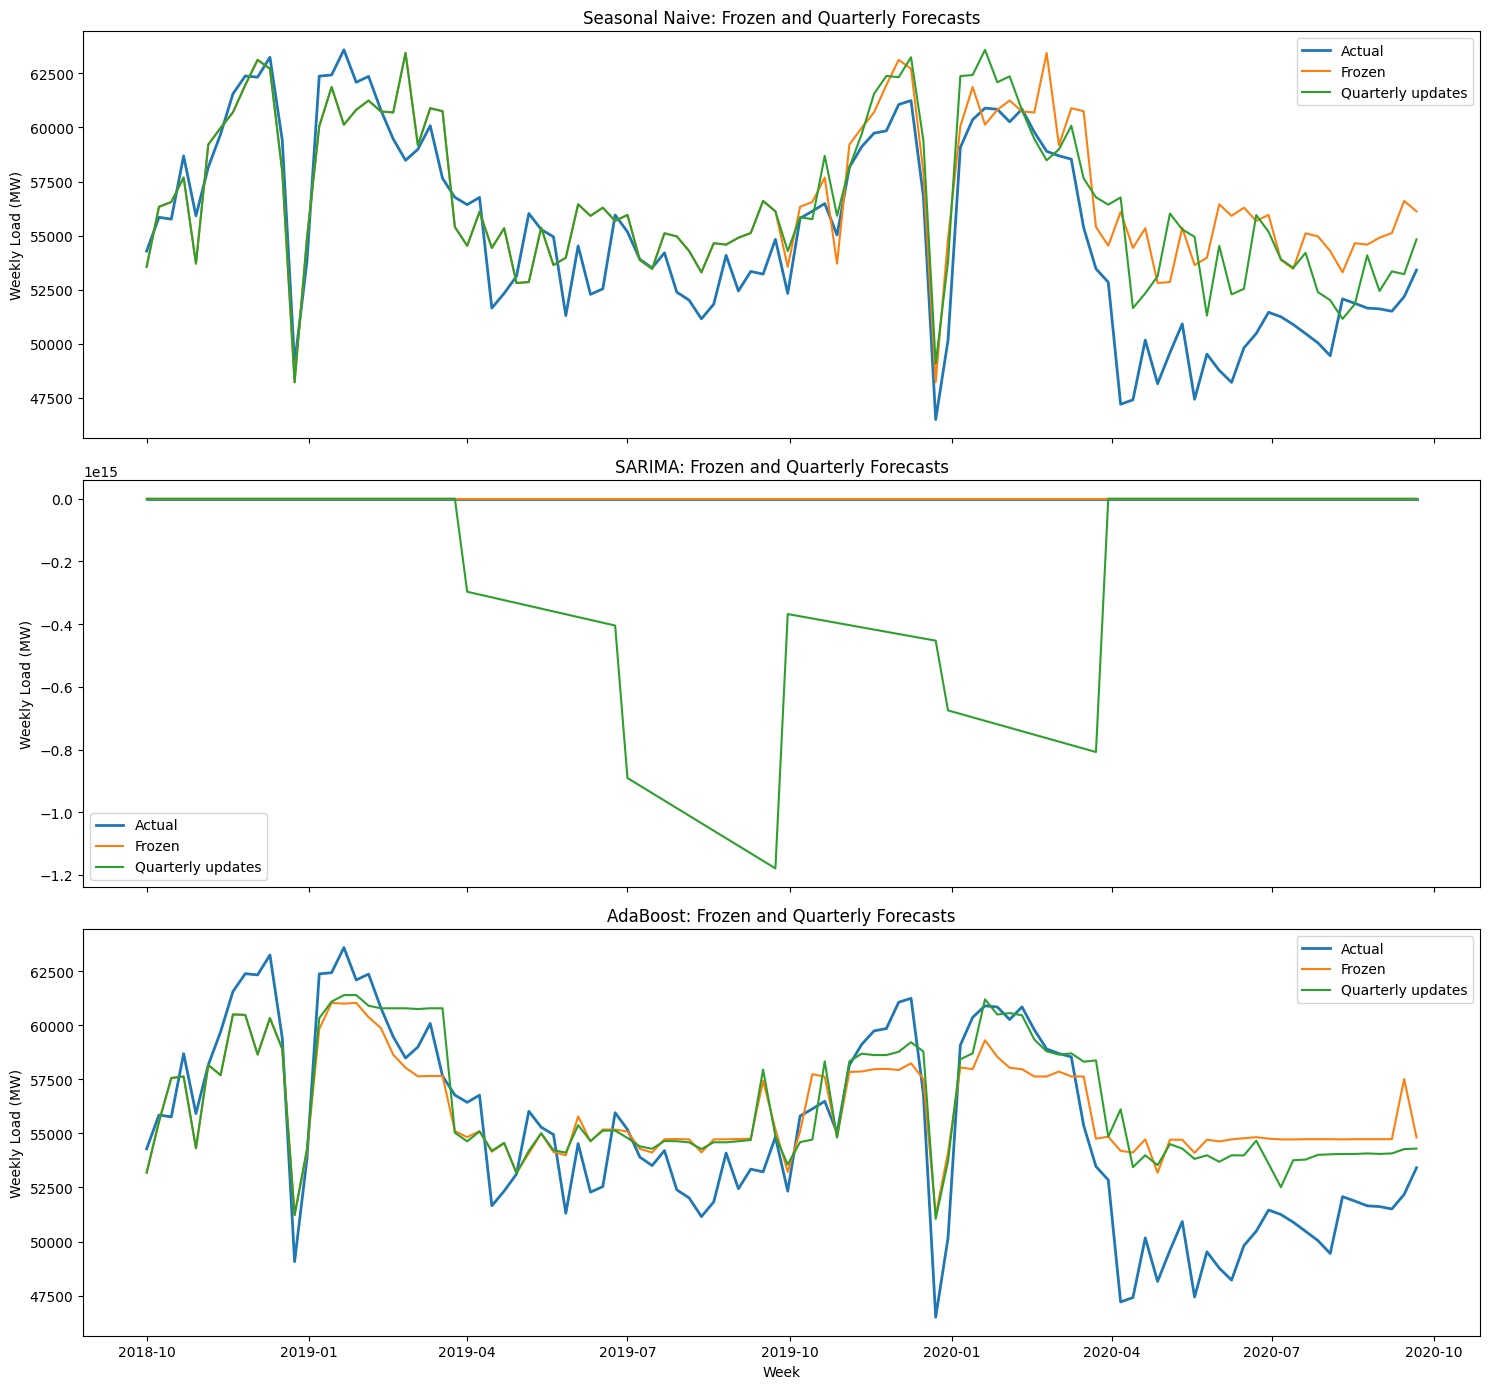

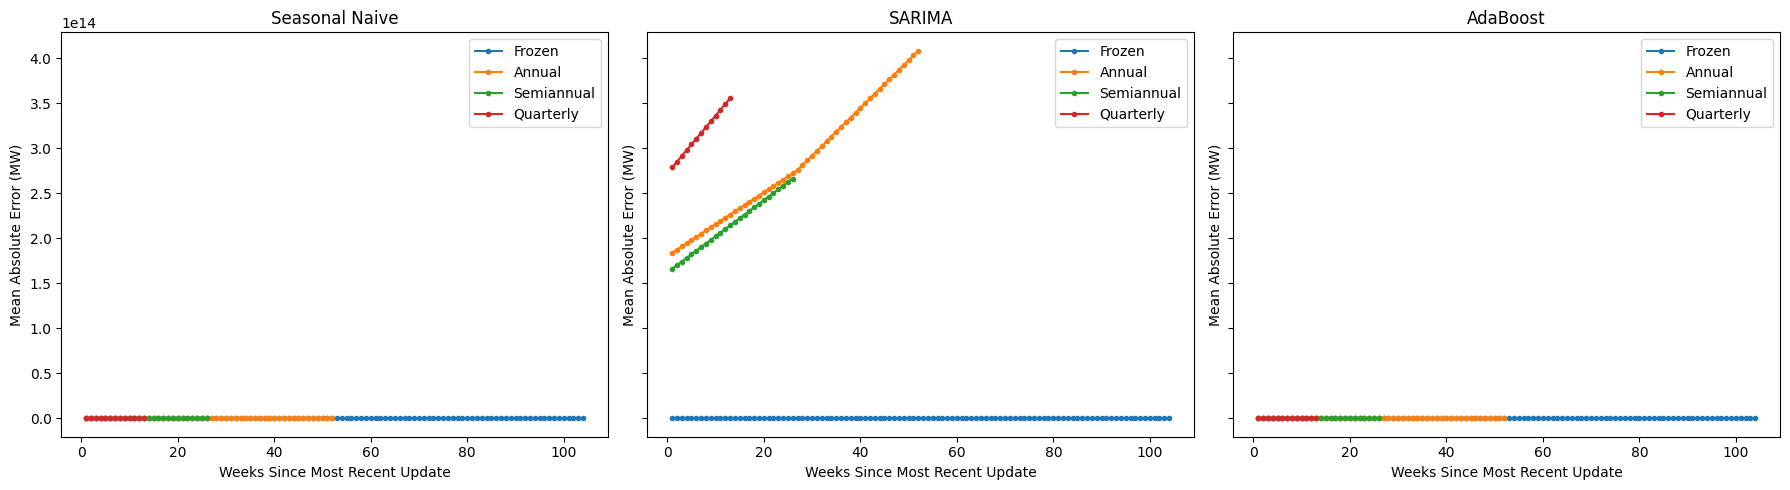

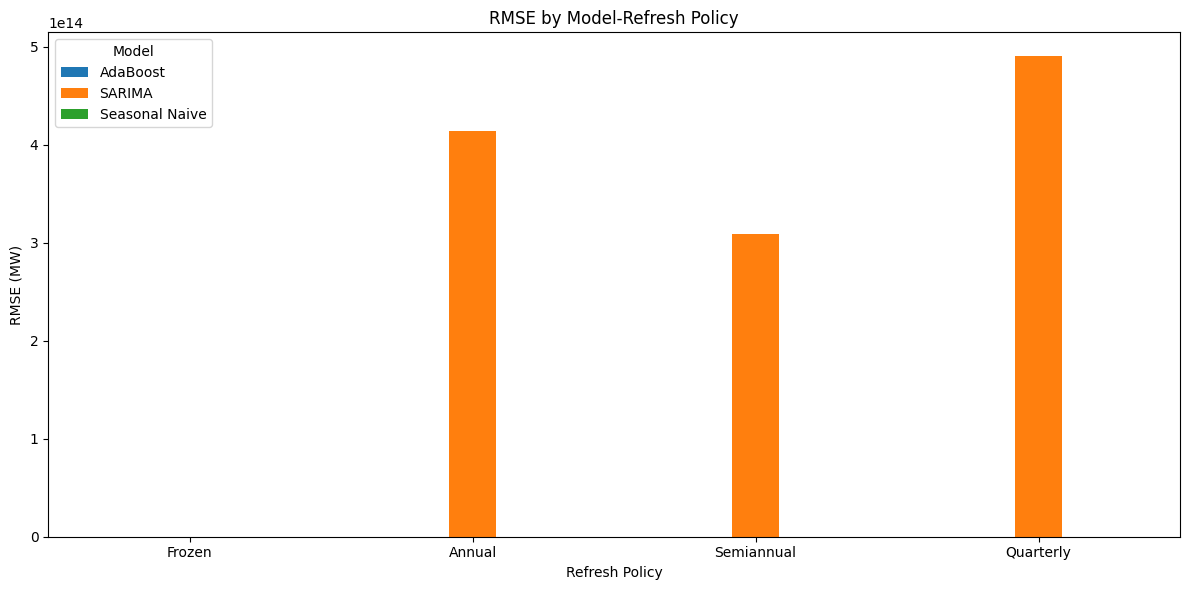

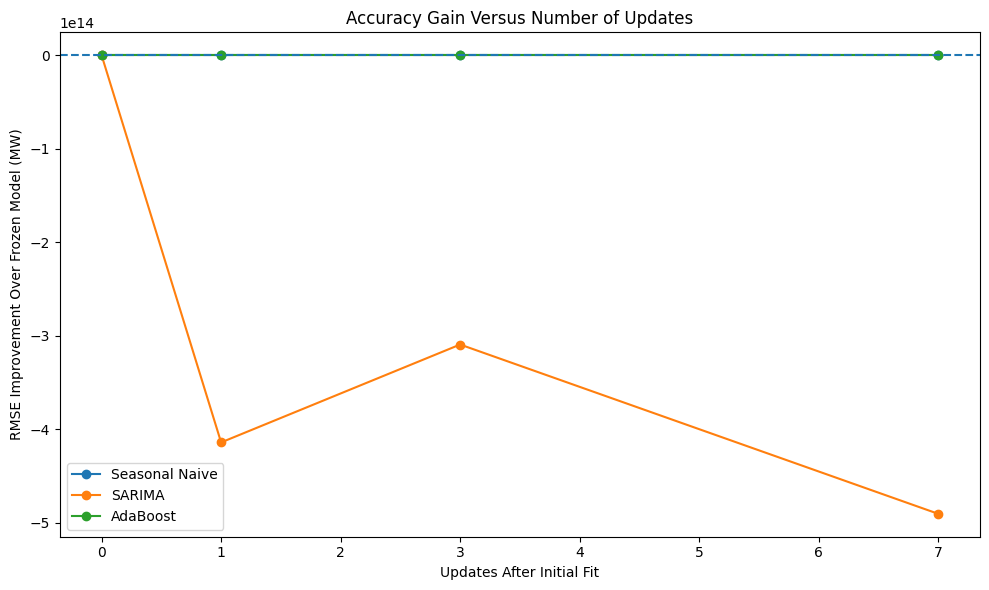

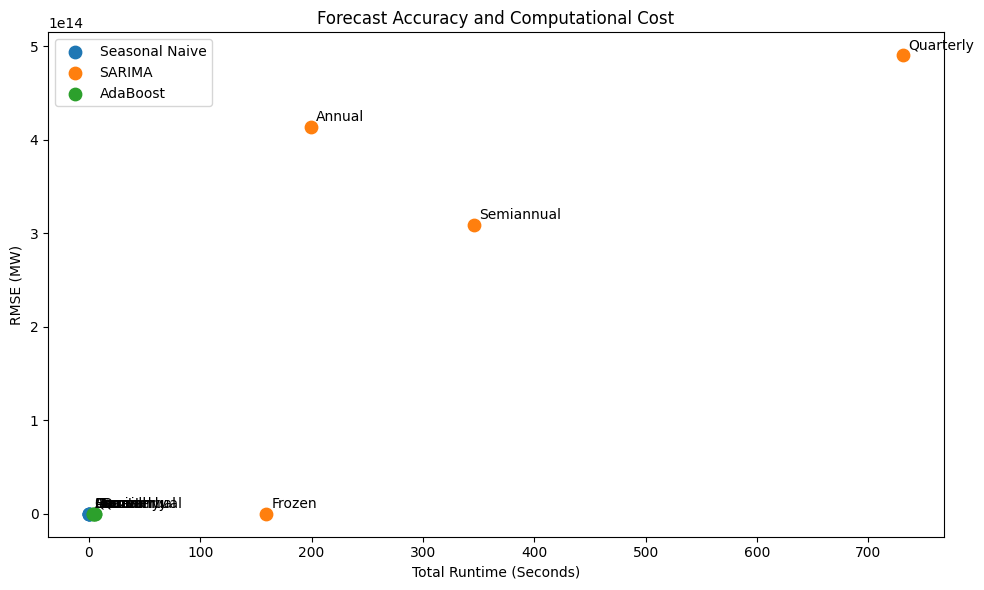

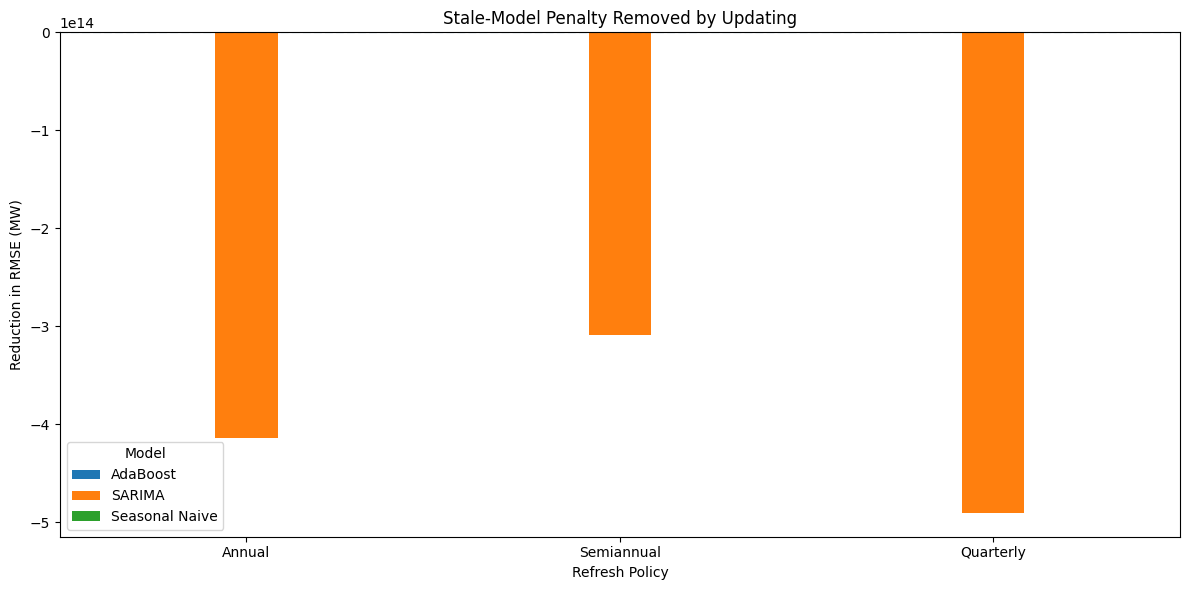

Cell 9 completed successfully.


In [ ]:
# ==============================================================
# CELL 9: FORECAST STALENESS ANALYSIS
# ==============================================================
# This cell calculates:
# 1. Policy-level accuracy.
# 2. Stale-model penalty.
# 3. Gain per update.
# 4. Error-growth slope.
# 5. Runtime and maintenance requirements.
# ==============================================================


# ==============================================================
# 1. SUMMARISE EACH MODEL AND POLICY
# ==============================================================

summary_records = []

for (
    model_name,
    policy_name
), group in refresh_predictions.groupby(
    [
        "Model",
        "Policy"
    ]
):

    actual_values = group[
        "Actual"
    ].to_numpy()

    predicted_values = group[
        "Prediction"
    ].to_numpy()

    errors = group[
        "Error"
    ].to_numpy()

    absolute_errors = group[
        "Absolute error"
    ].to_numpy()

    interval = REFRESH_POLICIES[
        policy_name
    ]

    schedule = make_refresh_schedule(
        len(test_weekly),
        interval
    )

    total_fits = len(schedule)
    number_of_updates = total_fits - 1

    total_runtime = refresh_run_log.loc[
        (
            refresh_run_log["Model"]
            == model_name
        )
        & (
            refresh_run_log["Policy"]
            == policy_name
        ),
        "Runtime seconds"
    ].sum()

    # Relationship between model age and absolute error.
    slope_result = stats.linregress(
        group["Weeks since update"],
        group["Absolute error"]
    )

    summary_records.append(
        {
            "Model": model_name,
            "Policy": policy_name,
            "Update interval": (
                "No update"
                if interval is None
                else f"{interval} weeks"
            ),
            "Updates": number_of_updates,
            "Total fits": total_fits,
            "MAE": mean_absolute_error(
                actual_values,
                predicted_values
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    actual_values,
                    predicted_values
                )
            ),
            "sMAPE (%)": smape(
                actual_values,
                predicted_values
            ),
            "Bias": np.mean(errors),
            "Error stability": np.std(
                absolute_errors,
                ddof=1
            ),
            "Error-growth slope": (
                slope_result.slope
            ),
            "Runtime seconds": total_runtime,
            "Maintenance": maintenance_level(
                total_fits
            )
        }
    )


refresh_summary = pd.DataFrame(
    summary_records
)


# ==============================================================
# 2. CALCULATE STALE-MODEL PENALTY
# ==============================================================

frozen_rmse = (
    refresh_summary.loc[
        refresh_summary["Policy"]
        == "Frozen",
        [
            "Model",
            "RMSE"
        ]
    ]
    .set_index("Model")[
        "RMSE"
    ]
)

refresh_summary["Frozen RMSE"] = (
    refresh_summary[
        "Model"
    ].map(
        frozen_rmse
    )
)

refresh_summary[
    "Improvement over frozen"
] = (
    refresh_summary["Frozen RMSE"]
    - refresh_summary["RMSE"]
)

refresh_summary[
    "Improvement over frozen (%)"
] = (
    refresh_summary[
        "Improvement over frozen"
    ]
    / refresh_summary["Frozen RMSE"]
    * 100
)

refresh_summary[
    "Gain per update"
] = np.where(
    refresh_summary["Updates"] > 0,
    refresh_summary[
        "Improvement over frozen"
    ]
    / refresh_summary["Updates"],
    0
)

refresh_summary = (
    refresh_summary
    .sort_values(
        [
            "Model",
            "RMSE"
        ]
    )
    .reset_index(drop=True)
)

display(
    refresh_summary.round(4)
)


# ==============================================================
# PLOT 1: FROZEN VS QUARTERLY FORECASTS
# ==============================================================

models_to_plot = [
    "Seasonal Naive",
    "SARIMA",
    "AdaBoost"
]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 14),
    sharex=True
)

for ax, model_name in zip(
    axes,
    models_to_plot
):

    actual_series = (
        refresh_predictions.loc[
            refresh_predictions["Model"]
            == model_name,
            [
                "Forecast date",
                "Actual"
            ]
        ]
        .drop_duplicates(
            "Forecast date"
        )
        .set_index(
            "Forecast date"
        )["Actual"]
    )

    frozen_series = (
        refresh_predictions.loc[
            (
                refresh_predictions["Model"]
                == model_name
            )
            & (
                refresh_predictions["Policy"]
                == "Frozen"
            )
        ]
        .set_index(
            "Forecast date"
        )["Prediction"]
    )

    quarterly_series = (
        refresh_predictions.loc[
            (
                refresh_predictions["Model"]
                == model_name
            )
            & (
                refresh_predictions["Policy"]
                == "Quarterly"
            )
        ]
        .set_index(
            "Forecast date"
        )["Prediction"]
    )

    ax.plot(
        actual_series.index,
        actual_series.values,
        linewidth=2,
        label="Actual"
    )

    ax.plot(
        frozen_series.index,
        frozen_series.values,
        label="Frozen"
    )

    ax.plot(
        quarterly_series.index,
        quarterly_series.values,
        label="Quarterly updates"
    )

    ax.set_title(
        f"{model_name}: Frozen and Quarterly Forecasts"
    )

    ax.set_ylabel(
        "Weekly Load (MW)"
    )

    ax.legend()

axes[-1].set_xlabel("Week")

save_figure(
    "frozen_vs_quarterly_forecasts",
    fig
)

plt.show()


# ==============================================================
# PLOT 2: ERROR AGAINST WEEKS SINCE UPDATE
# ==============================================================

age_error = (
    refresh_predictions
    .groupby(
        [
            "Model",
            "Policy",
            "Weeks since update"
        ]
    )[
        "Absolute error"
    ]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharey=True
)

for ax, model_name in zip(
    axes,
    models_to_plot
):

    model_age_data = age_error.loc[
        age_error["Model"]
        == model_name
    ]

    for policy_name in REFRESH_POLICIES:

        policy_data = model_age_data.loc[
            model_age_data["Policy"]
            == policy_name
        ]

        ax.plot(
            policy_data[
                "Weeks since update"
            ],
            policy_data[
                "Absolute error"
            ],
            marker="o",
            markersize=3,
            label=policy_name
        )

    ax.set_title(model_name)

    ax.set_xlabel(
        "Weeks Since Most Recent Update"
    )

    ax.set_ylabel(
        "Mean Absolute Error (MW)"
    )

    ax.legend()

save_figure(
    "error_by_model_age",
    fig
)

plt.show()


# ==============================================================
# PLOT 3: RMSE BY REFRESH POLICY
# ==============================================================

policy_order = [
    "Frozen",
    "Annual",
    "Semiannual",
    "Quarterly"
]

rmse_pivot = refresh_summary.pivot(
    index="Policy",
    columns="Model",
    values="RMSE"
).reindex(
    policy_order
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

rmse_pivot.plot.bar(
    ax=ax
)

ax.set_title(
    "RMSE by Model-Refresh Policy"
)

ax.set_xlabel("Refresh Policy")
ax.set_ylabel("RMSE (MW)")

ax.tick_params(
    axis="x",
    rotation=0
)

ax.legend(
    title="Model"
)

save_figure(
    "rmse_by_refresh_policy",
    fig
)

plt.show()


# ==============================================================
# PLOT 4: ACCURACY GAIN AGAINST NUMBER OF UPDATES
# ==============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

for model_name in models_to_plot:

    model_data = (
        refresh_summary.loc[
            refresh_summary["Model"]
            == model_name
        ]
        .sort_values("Updates")
    )

    ax.plot(
        model_data["Updates"],
        model_data[
            "Improvement over frozen"
        ],
        marker="o",
        label=model_name
    )

ax.axhline(
    0,
    linestyle="--"
)

ax.set_title(
    "Accuracy Gain Versus Number of Updates"
)

ax.set_xlabel(
    "Updates After Initial Fit"
)

ax.set_ylabel(
    "RMSE Improvement Over Frozen Model (MW)"
)

ax.legend()

save_figure(
    "accuracy_gain_vs_updates",
    fig
)

plt.show()


# ==============================================================
# PLOT 5: RUNTIME VERSUS RMSE
# ==============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

for model_name in models_to_plot:

    model_data = refresh_summary.loc[
        refresh_summary["Model"]
        == model_name
    ]

    ax.scatter(
        model_data[
            "Runtime seconds"
        ],
        model_data["RMSE"],
        s=80,
        label=model_name
    )

    for _, row in model_data.iterrows():

        ax.annotate(
            row["Policy"],
            (
                row["Runtime seconds"],
                row["RMSE"]
            ),
            xytext=(4, 4),
            textcoords="offset points"
        )

ax.set_title(
    "Forecast Accuracy and Computational Cost"
)

ax.set_xlabel(
    "Total Runtime (Seconds)"
)

ax.set_ylabel("RMSE (MW)")
ax.legend()

save_figure(
    "runtime_vs_rmse",
    fig
)

plt.show()


# ==============================================================
# PLOT 6: STALE-MODEL PENALTY REMOVED
# ==============================================================

updated_only = refresh_summary.loc[
    refresh_summary["Policy"]
    != "Frozen"
].copy()

penalty_pivot = updated_only.pivot(
    index="Policy",
    columns="Model",
    values="Improvement over frozen"
).reindex(
    [
        "Annual",
        "Semiannual",
        "Quarterly"
    ]
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

penalty_pivot.plot.bar(
    ax=ax
)

ax.axhline(
    0,
    linestyle="--"
)

ax.set_title(
    "Stale-Model Penalty Removed by Updating"
)

ax.set_xlabel("Refresh Policy")

ax.set_ylabel(
    "Reduction in RMSE (MW)"
)

ax.tick_params(
    axis="x",
    rotation=0
)

ax.legend(
    title="Model"
)

save_figure(
    "stale_model_penalty",
    fig
)

plt.show()


# ==============================================================
# SAVE SUMMARY
# ==============================================================

refresh_summary.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "refresh_policy_summary.csv"
    ),
    index=False
)

print("Cell 9 completed successfully.")

Alignment check passed: all forecasts use exactly the same dates.
TABLE 1: FIXED-ORIGIN MODEL COMPARISON


,Rank,Model,MAE,RMSE,sMAPE (%),Bias,Error stability,Skill vs Seasonal Naive
0,1,AdaBoost,2311.1520,2849.6594,4.2559,956.7092,1675.1468,0.0464
1,2,Seasonal Naive,2288.4892,2988.2483,4.2067,1747.8046,1930.8791,0.0000
2,3,Mean,3789.8453,4402.0588,6.8738,561.1923,2250.3079,-0.4731
3,4,Drift,3850.7758,4466.4944,6.9823,966.3860,2273.9432,-0.4947
4,5,Naive,3858.1478,4475.7671,6.9954,984.5335,2279.7279,-0.4978
5,6,LSTM,4167.3802,4855.5364,7.5381,2124.0717,2503.8887,-0.6249
6,7,SARIMAX Full,4344.4302,5285.8987,7.7441,4294.0230,3025.6697,-0.7689
7,8,SARIMA,5159.2834,6244.1333,9.0854,5095.9542,3534.2754,-1.0896
8,9,SARIMAX Temperature,5885.9655,7107.0061,10.2744,5863.5004,4002.3712,-1.3783


TABLE 2: MODEL-UPDATE POLICY COMPARISON


,Model,Policy,Update interval,Updates,Total fits,MAE,RMSE,Improvement over frozen,Improvement over frozen (%),Gain per update,Error-growth slope,Bias,Runtime seconds,Maintenance
0,AdaBoost,Quarterly,13 weeks,7,8,2.055892e+03,2.636976e+03,2.126836e+02,7.463500e+00,3.038340e+01,5.249450e+01,1.156445e+03,5.9358,High
1,AdaBoost,Semiannual,26 weeks,3,4,2.100537e+03,2.674439e+03,1.752204e+02,6.148800e+00,5.840680e+01,-2.256650e+01,1.082646e+03,5.5153,Moderate
2,AdaBoost,Annual,52 weeks,1,2,2.160312e+03,2.789052e+03,6.060710e+01,2.126800e+00,6.060710e+01,3.278410e+01,1.142283e+03,3.7615,Moderate
3,AdaBoost,Frozen,No update,0,1,2.311152e+03,2.849659e+03,0.000000e+00,0.000000e+00,0.000000e+00,3.163960e+01,9.567092e+02,3.3881,Low
4,SARIMA,Frozen,No update,0,1,5.159283e+03,6.244133e+03,0.000000e+00,0.000000e+00,0.000000e+00,1.027072e+02,5.095954e+03,158.9181,Low
5,SARIMA,Semiannual,26 weeks,3,4,2.163356e+14,3.093841e+14,-3.093841e+14,-4.954796e+12,-1.031280e+14,4.012559e+12,-2.163356e+14,345.8774,Moderate
6,SARIMA,Annual,52 weeks,1,2,2.851934e+14,4.140770e+14,-4.140770e+14,-6.631457e+12,-4.140770e+14,4.394913e+12,-2.851934e+14,199.2148,Moderate
7,SARIMA,Quarterly,13 weeks,7,8,3.171980e+14,4.904197e+14,-4.904197e+14,-7.854087e+12,-7.005995e+13,6.389652e+12,-3.171980e+14,731.1630,High
8,Seasonal Naive,Annual,52 weeks,1,2,2.021174e+03,2.626004e+03,3.622446e+02,1.212230e+01,3.622446e+02,2.572670e+01,1.482576e+03,0.0504,Moderate
9,Seasonal Naive,Quarterly,13 weeks,7,8,2.021174e+03,2.626004e+03,3.622446e+02,1.212230e+01,5.174920e+01,-5.225900e+00,1.482576e+03,0.0517,High


Efficient refresh policy selected for each model:


,Model,Recommended policy,RMSE,Updates,Total fits,Runtime seconds,Maintenance,Uses observed future weather
0,AdaBoost,Semiannual,2674.4390,3,4,5.5153,Moderate,Yes
1,SARIMA,Frozen,6244.1333,0,1,158.9181,Low,No
2,Seasonal Naive,Annual,2626.0038,1,2,0.0504,Moderate,No



OPERATIONAL RECOMMENDATION
Recommended model : Seasonal Naive
Refresh policy    : Annual
RMSE              : 2626.00 MW
Updates           : 1
Maintenance level : Moderate


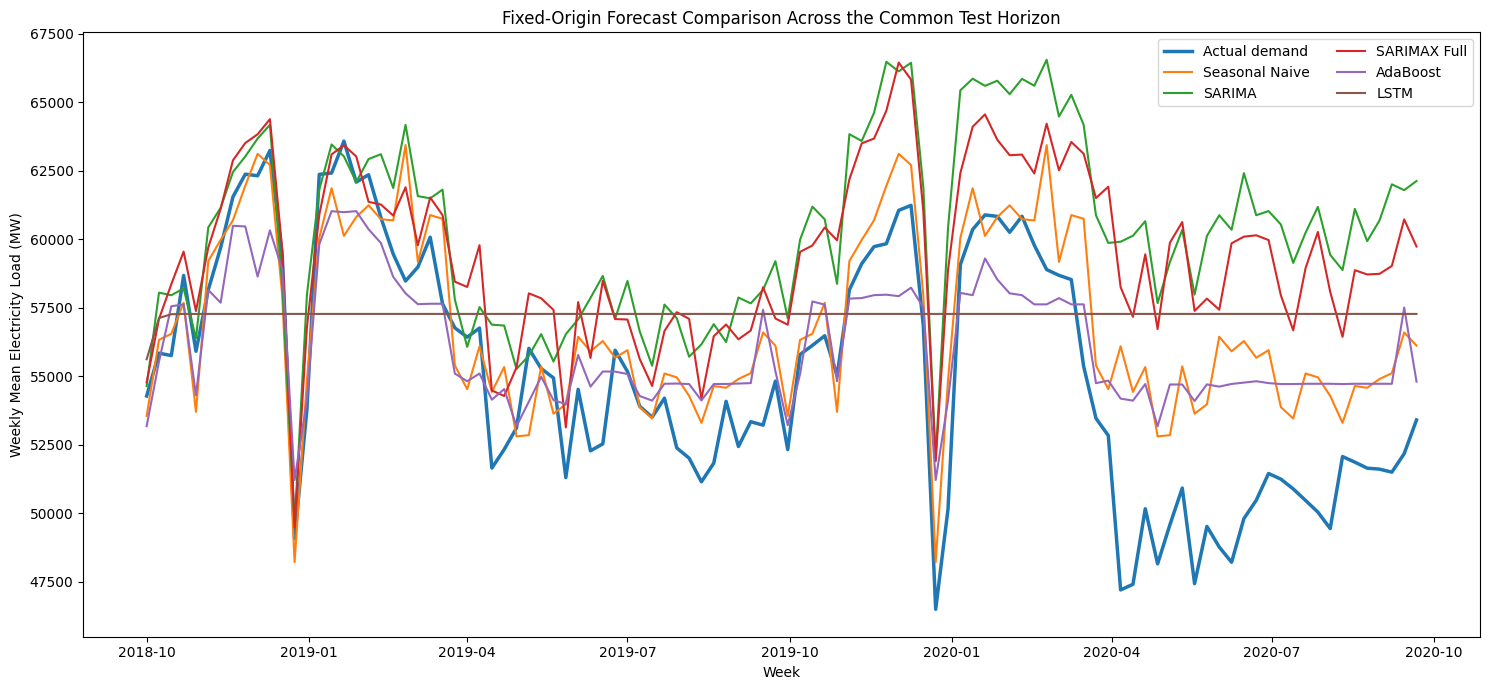


All figures, models, tables and logs were saved.
Project folder: /content/german_demand_refresh_project
Cell 10 completed successfully.


In [ ]:
# ==============================================================
# CELL 10: FINAL TABLES AND RECOMMENDATION
# ==============================================================
# This cell:
# 1. Creates the fixed-origin ranking.
# 2. Creates the update-policy comparison.
# 3. Selects efficient policies.
# 4. Produces the final forecast plot.
# 5. Saves final tables and the run manifest.
# ==============================================================


# ==============================================================
# 1. CHECK FIXED-ORIGIN FORECAST ALIGNMENT
# ==============================================================

check_forecast_alignment(
    forecast_store,
    test_weekly.index
)


# ==============================================================
# 2. TABLE 1: FIXED-ORIGIN METRICS
# ==============================================================

fixed_origin_metrics = pd.DataFrame(
    metrics_store
)

fixed_origin_metrics = (
    fixed_origin_metrics
    .drop_duplicates(
        subset="Model",
        keep="last"
    )
)

seasonal_naive_rmse = float(
    fixed_origin_metrics.loc[
        fixed_origin_metrics["Model"]
        == "Seasonal Naive",
        "RMSE"
    ].iloc[0]
)

fixed_origin_metrics[
    "Skill vs Seasonal Naive"
] = (
    1
    - fixed_origin_metrics["RMSE"]
    / seasonal_naive_rmse
)

fixed_origin_metrics = (
    fixed_origin_metrics
    .sort_values("RMSE")
    .reset_index(drop=True)
)

fixed_origin_metrics.insert(
    0,
    "Rank",
    np.arange(
        1,
        len(fixed_origin_metrics) + 1
    )
)

print("=" * 80)
print("TABLE 1: FIXED-ORIGIN MODEL COMPARISON")
print("=" * 80)

display(
    fixed_origin_metrics[
        [
            "Rank",
            "Model",
            "MAE",
            "RMSE",
            "sMAPE (%)",
            "Bias",
            "Error stability",
            "Skill vs Seasonal Naive"
        ]
    ].round(4)
)


# ==============================================================
# 3. TABLE 2: UPDATE-POLICY COMPARISON
# ==============================================================

update_policy_table = refresh_summary[
    [
        "Model",
        "Policy",
        "Update interval",
        "Updates",
        "Total fits",
        "MAE",
        "RMSE",
        "Improvement over frozen",
        "Improvement over frozen (%)",
        "Gain per update",
        "Error-growth slope",
        "Bias",
        "Runtime seconds",
        "Maintenance"
    ]
].copy()

print("=" * 80)
print("TABLE 2: MODEL-UPDATE POLICY COMPARISON")
print("=" * 80)

display(
    update_policy_table.round(4)
)


# ==============================================================
# 4. SELECT EFFICIENT POLICY FOR EACH MODEL
# ==============================================================

recommended_policy_records = []

for model_name in refresh_summary[
    "Model"
].unique():

    model_results = refresh_summary.loc[
        refresh_summary["Model"]
        == model_name
    ].copy()

    best_model_rmse = model_results[
        "RMSE"
    ].min()

    # Policies within 2% of the best RMSE are considered competitive.
    competitive_policies = model_results.loc[
        model_results["RMSE"]
        <= best_model_rmse * 1.02
    ].copy()

    selected_policy = (
        competitive_policies
        .sort_values(
            [
                "Total fits",
                "Runtime seconds",
                "RMSE"
            ]
        )
        .iloc[0]
    )

    recommended_policy_records.append(
        {
            "Model": model_name,
            "Recommended policy": (
                selected_policy["Policy"]
            ),
            "RMSE": selected_policy["RMSE"],
            "Updates": selected_policy["Updates"],
            "Total fits": selected_policy[
                "Total fits"
            ],
            "Runtime seconds": selected_policy[
                "Runtime seconds"
            ],
            "Maintenance": selected_policy[
                "Maintenance"
            ],
            "Uses observed future weather": (
                "Yes"
                if model_name == "AdaBoost"
                else "No"
            )
        }
    )


recommended_policies = pd.DataFrame(
    recommended_policy_records
)

print(
    "Efficient refresh policy selected for each model:"
)

display(
    recommended_policies.round(4)
)


# ==============================================================
# 5. OPERATIONAL RECOMMENDATION
# ==============================================================

operational_candidates = (
    recommended_policies.loc[
        recommended_policies[
            "Uses observed future weather"
        ] == "No"
    ]
    .copy()
)

operational_recommendation = (
    operational_candidates
    .sort_values(
        [
            "RMSE",
            "Total fits",
            "Runtime seconds"
        ]
    )
    .iloc[0]
)

print("\n" + "=" * 80)
print("OPERATIONAL RECOMMENDATION")
print("=" * 80)

print(
    f"Recommended model : "
    f"{operational_recommendation['Model']}"
)

print(
    f"Refresh policy    : "
    f"{operational_recommendation['Recommended policy']}"
)

print(
    f"RMSE              : "
    f"{operational_recommendation['RMSE']:.2f} MW"
)

print(
    f"Updates           : "
    f"{int(operational_recommendation['Updates'])}"
)

print(
    f"Maintenance level : "
    f"{operational_recommendation['Maintenance']}"
)


# ==============================================================
# FINAL COMMON-HORIZON FORECAST PLOT
# ==============================================================

selected_plot_models = [
    "Seasonal Naive",
    "SARIMA",
    "SARIMAX Full",
    "AdaBoost",
    "LSTM"
]

fig, ax = plt.subplots(
    figsize=(15, 7)
)

ax.plot(
    test_weekly.index,
    test_weekly.values,
    linewidth=2.5,
    label="Actual demand"
)

for model_name in selected_plot_models:

    ax.plot(
        forecast_store[
            model_name
        ].index,
        forecast_store[
            model_name
        ].values,
        label=model_name
    )

ax.set_title(
    "Fixed-Origin Forecast Comparison Across the Common Test Horizon"
)

ax.set_xlabel("Week")

ax.set_ylabel(
    "Weekly Mean Electricity Load (MW)"
)

ax.legend(
    ncol=2
)

save_figure(
    "final_fixed_origin_forecast_comparison",
    fig
)

plt.show()


# ==============================================================
# SAVE FINAL RESULTS
# ==============================================================

fixed_origin_metrics.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "fixed_origin_model_metrics.csv"
    ),
    index=False
)

update_policy_table.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "final_update_policy_table.csv"
    ),
    index=False
)

recommended_policies.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "recommended_refresh_policies.csv"
    ),
    index=False
)

pd.DataFrame(
    interval_store
).to_csv(
    os.path.join(
        RESULT_FOLDER,
        "prediction_interval_metrics.csv"
    ),
    index=False
)

# Save all fixed-origin predictions in one table.
fixed_forecast_table = pd.DataFrame(
    {
        "Actual": test_weekly,
        **{
            model_name: forecast
            for model_name, forecast
            in forecast_store.items()
        }
    }
)

fixed_forecast_table.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "all_fixed_origin_forecasts.csv"
    )
)


# ==============================================================
# SAVE RUN MANIFEST
# ==============================================================

run_manifest = {
    "random_seed": RANDOM_SEED,
    "seasonal_period": SEASONAL_PERIOD,
    "test_weeks": TEST_WEEKS,
    "hourly_observations": len(hourly_load),
    "daily_observations": len(daily_load),
    "weekly_observations": len(weekly_load),
    "training_weeks": len(train_weekly),
    "testing_weeks": len(test_weekly),
    "training_start": str(
        train_weekly.index.min().date()
    ),
    "training_end": str(
        train_weekly.index.max().date()
    ),
    "testing_start": str(
        test_weekly.index.min().date()
    ),
    "testing_end": str(
        test_weekly.index.max().date()
    ),
    "selected_sarima_order": str(
        selected_order
    ),
    "selected_seasonal_order": str(
        seasonal_order
    ),
    "adaboost_parameters": {
        key: str(value)
        for key, value
        in adaboost_search.best_params_.items()
    },
    "selected_lstm_architecture": (
        best_architecture_name
    ),
    "selected_lstm_epochs": int(
        selected_epochs
    ),
    "refresh_policies": (
        REFRESH_POLICIES
    ),
    "operational_recommendation": {
        "model": operational_recommendation[
            "Model"
        ],
        "policy": operational_recommendation[
            "Recommended policy"
        ],
        "rmse": float(
            operational_recommendation[
                "RMSE"
            ]
        )
    }
}

with open(
    os.path.join(
        LOG_FOLDER,
        "run_manifest.json"
    ),
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        run_manifest,
        file,
        indent=4
    )

print("\nAll figures, models, tables and logs were saved.")
print(f"Project folder: {PROJECT_FOLDER}")
print("Cell 10 completed successfully.")